In [6]:
!ls /kaggle/input

datasets


In [7]:
!find /kaggle/input/datasets -maxdepth 4 -type f | head -50

/kaggle/input/datasets/raulagayev/real-or-fake/cnn-ai-image-generalization/.gitignore
/kaggle/input/datasets/raulagayev/real-or-fake/cnn-ai-image-generalization/validate_evaluation.py
/kaggle/input/datasets/raulagayev/real-or-fake/cnn-ai-image-generalization/milestone1.ipynb
/kaggle/input/datasets/raulagayev/real-or-fake/cnn-ai-image-generalization/README.md
/kaggle/input/datasets/raulagayev/real-or-fake/cnn-ai-image-generalization/validate_dataset.py
/kaggle/input/datasets/raulagayev/real-or-fake/cnn-ai-image-generalization/requirements.txt
/kaggle/input/datasets/raulagayev/real-or-fake/cnn-ai-image-generalization/validate_architecture.py


In [8]:
!cp -r /kaggle/input/datasets/raulagayev/real-or-fake/cnn-ai-image-generalization /kaggle/working/


In [9]:
%cd /kaggle/working/cnn-ai-image-generalization
!python scripts/run_experiments.py --time_budget_hours 4 --batch_size 32


/kaggle/working/cnn-ai-image-generalization
Using device: cuda
Experiment budget: 4.00 hours
Planned combinations: 4
Running: arch=baseline, aug=0.5, drop=0.3
Starting training: arch=baseline, aug=0.5, drop=0.3, epochs=8, lr=0.001
Train: 100%|████████████████| 1/1 [00:01<00:00,  1.37s/it, acc=18.8, loss=0.776]
Epoch 1/8 | Train Loss: 0.7758 Acc: 18.75% | Val Loss: 0.6949 Acc: 43.75% F1: 0.3043
Train: 100%|████████████████| 1/1 [00:00<00:00, 52.40it/s, acc=68.8, loss=0.637]
Epoch 2/8 | Train Loss: 0.6374 Acc: 68.75% | Val Loss: 0.6903 Acc: 56.25% F1: 0.3600
Train: 100%|████████████████| 1/1 [00:00<00:00, 54.49it/s, acc=56.2, loss=0.762]
Epoch 3/8 | Train Loss: 0.7625 Acc: 56.25% | Val Loss: 0.6874 Acc: 56.25% F1: 0.3600
Train: 100%|████████████████| 1/1 [00:00<00:00, 56.49it/s, acc=62.5, loss=0.809]
Epoch 4/8 | Train Loss: 0.8092 Acc: 62.50% | Val Loss: 0.6866 Acc: 56.25% F1: 0.3600
Early stopping triggered. No improvement for 2 epochs.

EVALUATION: baseline_aug0.5_drop0.3

EVALUATION M

In [10]:
import torch
print(torch.cuda.is_available())


True


In [11]:
!find /kaggle/input -maxdepth 5 -type d | head -80


/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/tristanzhang32
/kaggle/input/datasets/tristanzhang32/ai-generated-images-vs-real-images
/kaggle/input/datasets/tristanzhang32/ai-generated-images-vs-real-images/test
/kaggle/input/datasets/tristanzhang32/ai-generated-images-vs-real-images/test/fake
/kaggle/input/datasets/tristanzhang32/ai-generated-images-vs-real-images/test/real
/kaggle/input/datasets/tristanzhang32/ai-generated-images-vs-real-images/train
/kaggle/input/datasets/tristanzhang32/ai-generated-images-vs-real-images/train/fake
/kaggle/input/datasets/tristanzhang32/ai-generated-images-vs-real-images/train/real
/kaggle/input/datasets/raulagayev
/kaggle/input/datasets/raulagayev/real-or-fake
/kaggle/input/datasets/raulagayev/real-or-fake/cnn-ai-image-generalization
/kaggle/input/datasets/raulagayev/real-or-fake/cnn-ai-image-generalization/scripts
/kaggle/input/datasets/raulagayev/real-or-fake/cnn-ai-image-generalization/results_smoke
/kaggle/input/datasets/raulagayev

In [12]:
!cp -r /kaggle/input/datasets/raulagayev/real-or-fake/cnn-ai-image-generalization /kaggle/working/
%cd /kaggle/working/cnn-ai-image-generalization


/kaggle/working/cnn-ai-image-generalization


In [14]:
!rm -rf /kaggle/working/data
!mkdir -p /kaggle/working/data

!ln -s /kaggle/input/datasets/tristanzhang32/ai-generated-images-vs-real-images/train /kaggle/working/data/train_subset
!ln -s /kaggle/input/datasets/tristanzhang32/ai-generated-images-vs-real-images/test /kaggle/working/data/test_subset


In [18]:
!python scripts/run_experiments.py \
  --data_dir /kaggle/working/data \
  --time_budget_hours 4 \
  --batch_size 64 \
  --num_workers 2 \
  --architectures baseline,resnet18 \
  --augmentation_strengths 0.5 \
  --dropout_rates 0.3 \
  --epochs_baseline 3 \
  --epochs_resnet 2 \
  --patience 1


Using device: cuda
Experiment budget: 4.00 hours
Planned combinations: 2
Running: arch=baseline, aug=0.5, drop=0.3
Starting training: arch=baseline, aug=0.5, drop=0.3, epochs=3, lr=0.001
Train:   5%|▋            | 40/750 [01:57<36:48,  3.11s/it, acc=60.2, loss=0.617]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Train:   6%|▊            | 44/750 [02:07<33:18,  2.83s/it, acc=60.5, loss=0.652]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Train:  13%|█▋           | 98/750 [04:59<35:59,  3.31s/it, acc=60.3, loss=0.683]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (107184040 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
Train:  24%|██▉

In [ ]:
from pathlib import Path
from IPython.display import Image, display
import pandas as pd

display(pd.read_csv("/kaggle/working/results/experiments.csv"))

for img in Path("/kaggle/working/results/reports").glob("*/*.png"):
    print(img)
    display(Image(filename=str(img)))


In [20]:
!python scripts/run_experiments.py \
  --data_dir /kaggle/working/data \
  --time_budget_hours 3 \
  --batch_size 64 \
  --num_workers 2 \
  --architectures resnet18 \
  --augmentation_strengths 0.5 \
  --dropout_rates 0.3 \
  --epochs_resnet 1 \
  --patience 1


Using device: cuda
Experiment budget: 3.00 hours
Planned combinations: 1
Running: arch=resnet18, aug=0.5, drop=0.3
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
Starting training: arch=resnet18, aug=0.5, drop=0.3, epochs=1, lr=0.0003
Train:   5%|▋            | 40/750 [02:05<36:06,  3.05s/it, acc=62.3, loss=0.518]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Train:   6%|▊            | 44/750 [02:15<31:53,

In [22]:
!pip install pandas

architecture,augmentation_strength,dropout_rate,train_time_sec,final_val_loss,final_val_acc,final_precision,final_recall,final_f1,roc_auc,checkpoint_path,history_path,report_dir
baseline,0.5,0.3,1.81,0.6866341829299927,0.5625,0.28125,0.5,0.36,0.38095238095238093,/kaggle/working/results/baseline_aug0.5_drop0.3/best.pth,/kaggle/working/results/baseline_aug0.5_drop0.3/history.json,/kaggle/working/results/reports/baseline_aug0.5_drop0.3
baseline,1.0,0.3,0.09,0.6886512041091919,0.5625,0.28125,0.5,0.36,0.7777777777777778,/kaggle/working/results/baseline_aug1.0_drop0.3/best.pth,/kaggle/working/results/baseline_aug1.0_drop0.3/history.json,/kaggle/working/results/reports/baseline_aug1.0_drop0.3
resnet18,0.5,0.3,1.24,0.24706006050109863,1.0,1.0,1.0,1.0,1.0,/kaggle/working/results/resnet18_aug0.5_drop0.3/best.pth,/kaggle/working/results/resnet18_aug0.5_drop0.3/history.json,/kaggle/working/results/reports/resnet18_aug0.5_drop0.3
resnet18,1.0,0.3,0.95,0.19937214255332947,1.0,1.0,1.0,1.0,1.0,/kaggle/working/results/resnet18_aug1.0_drop0.3/best.pth,/kaggle/working/results/resnet18_aug1.0_drop0.3/history.json,/kaggle/working/results/reports/resnet18_aug1.0_drop0.3
resnet18,0.5,0.3,3128.76,0.5387784461391733,0.7319166666666667,0.7631470208930036,0.7319166666666667,0.7237194041193505,0.8435504444444445,/kaggle/working/results/resnet18_aug0.5_drop0.3/best.pth,/kaggle/working/results/resnet18_aug0.5_drop0.3/history.json,/kaggle/working/results/reports/resnet18_aug0.5_drop0.3


/kaggle/working/results/reports/resnet18_aug0.5_drop0.3/roc_curve.png


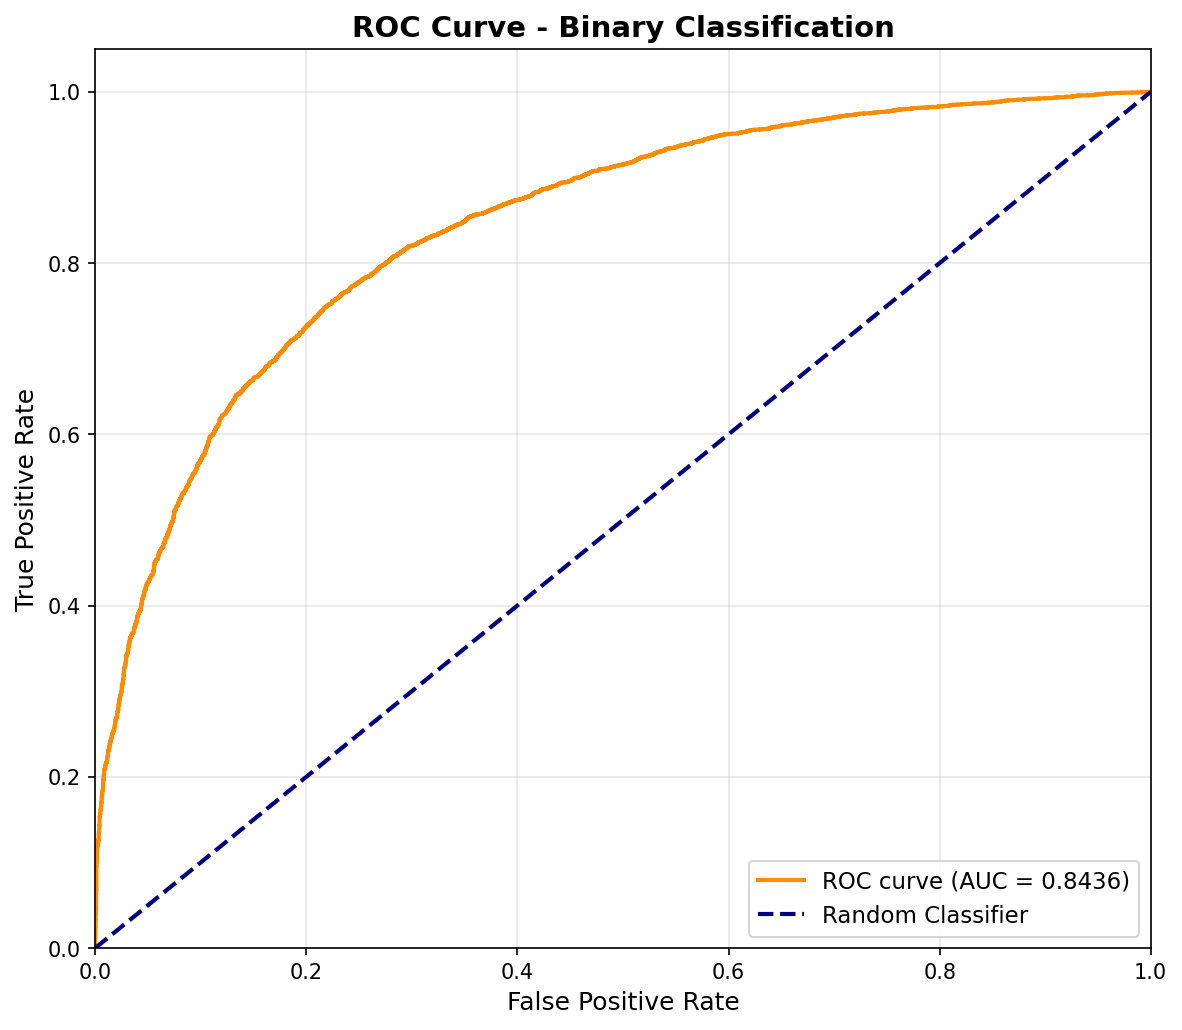

/kaggle/working/results/reports/resnet18_aug0.5_drop0.3/confusion_matrix.png


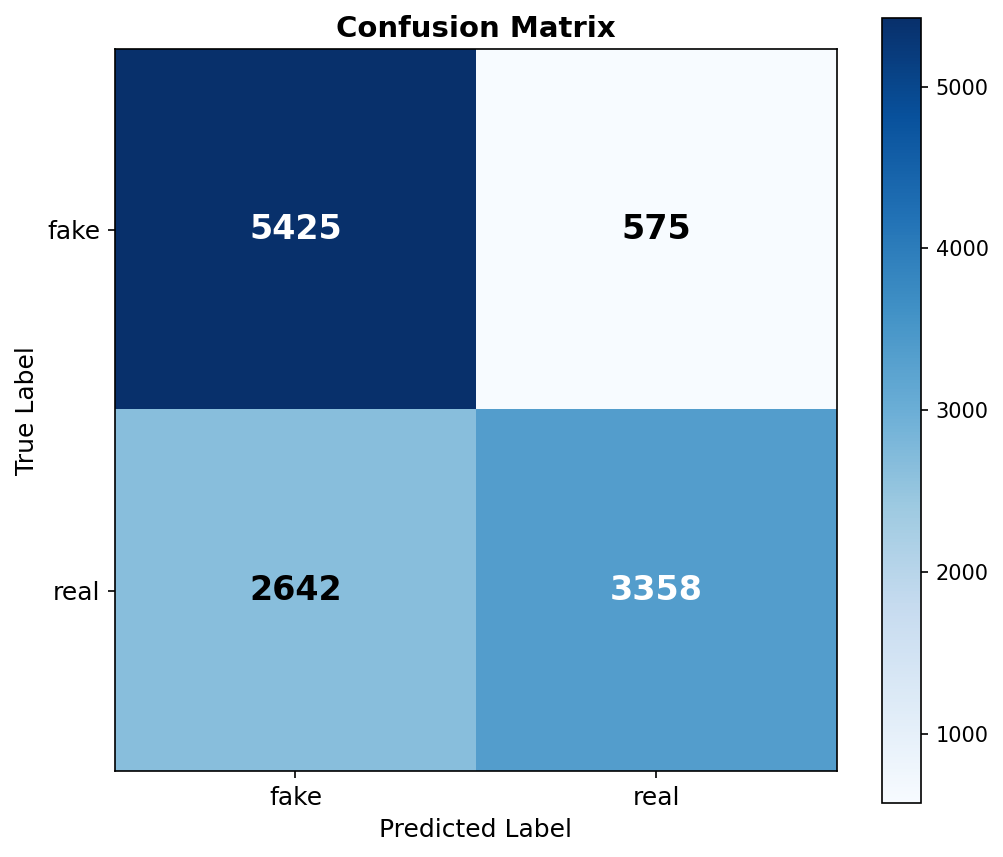

/kaggle/working/results/reports/baseline_aug0.5_drop0.3/roc_curve.png


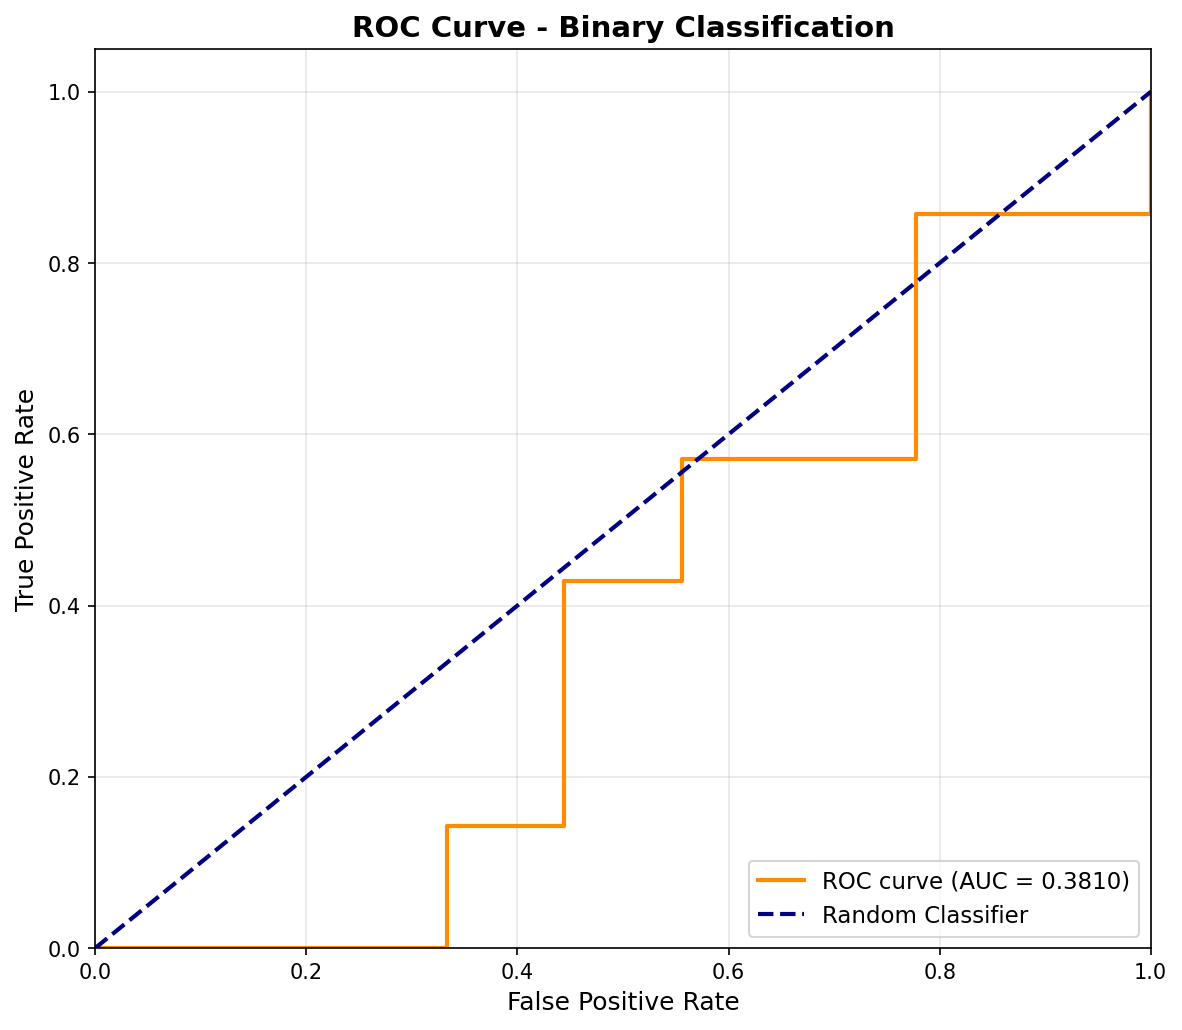

/kaggle/working/results/reports/baseline_aug0.5_drop0.3/confusion_matrix.png


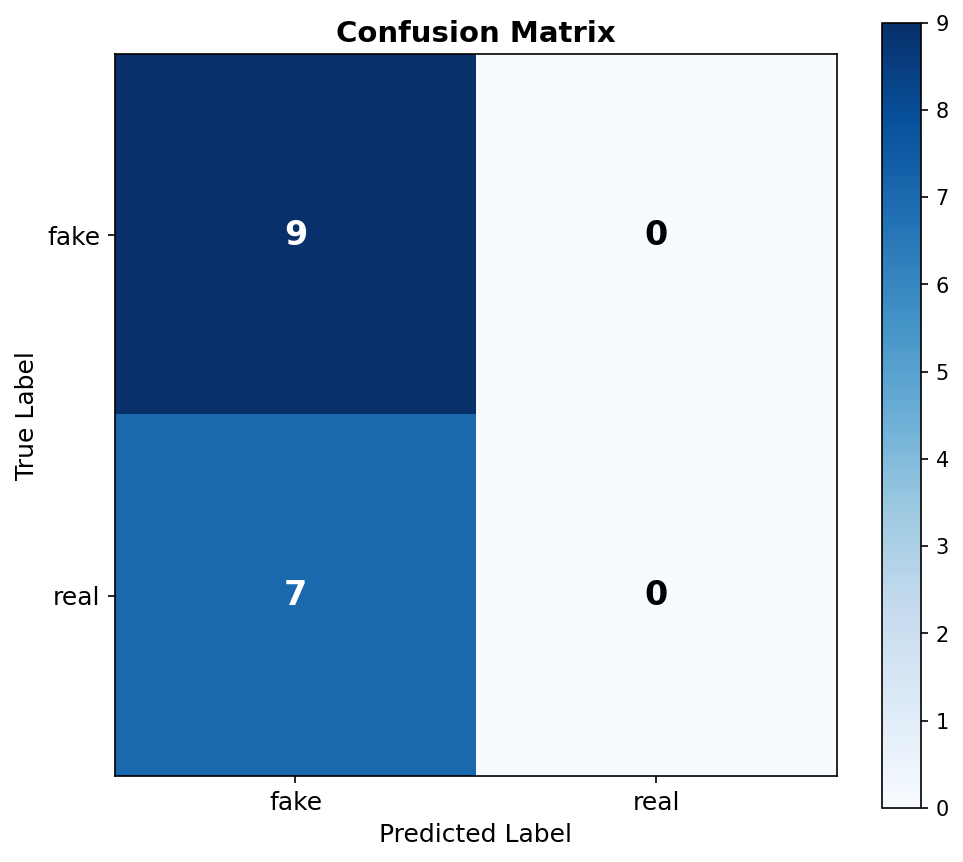

/kaggle/working/results/reports/resnet18_aug1.0_drop0.3/roc_curve.png


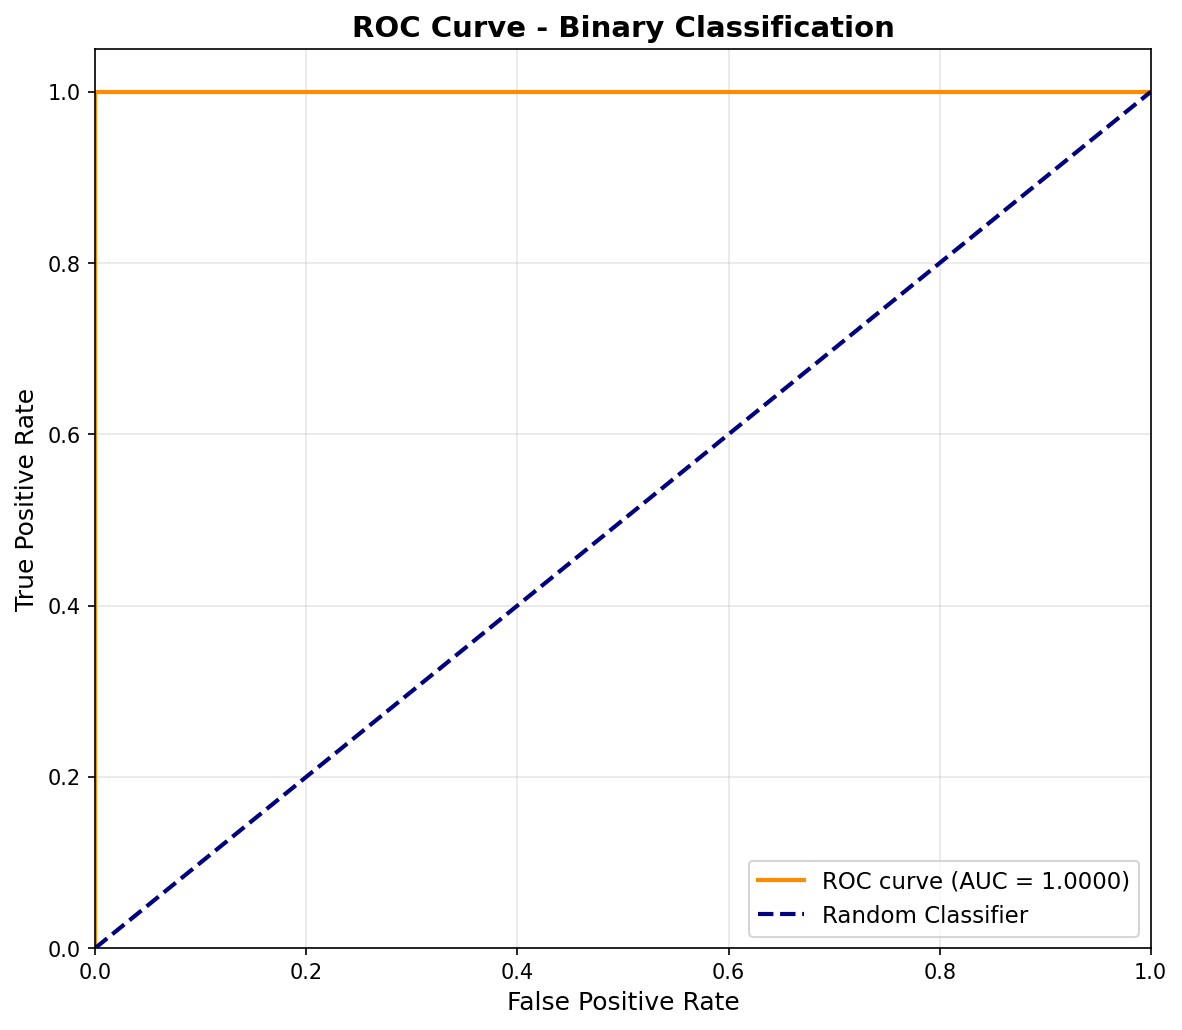

/kaggle/working/results/reports/resnet18_aug1.0_drop0.3/confusion_matrix.png


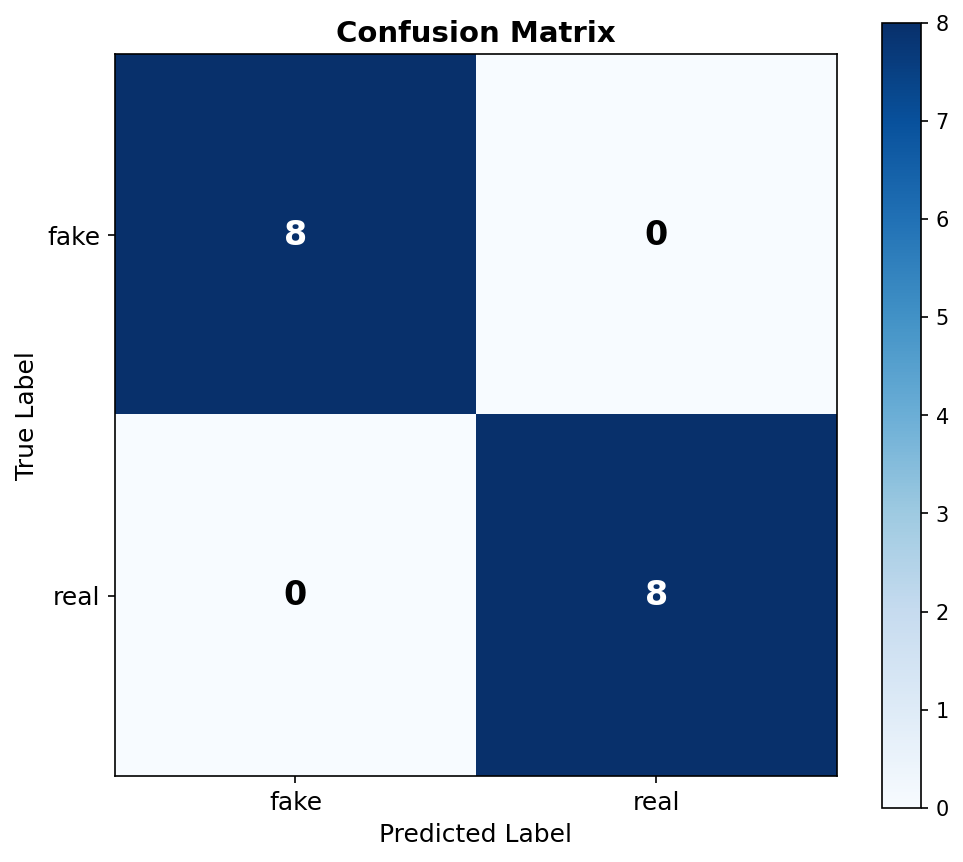

/kaggle/working/results/reports/baseline_aug1.0_drop0.3/roc_curve.png


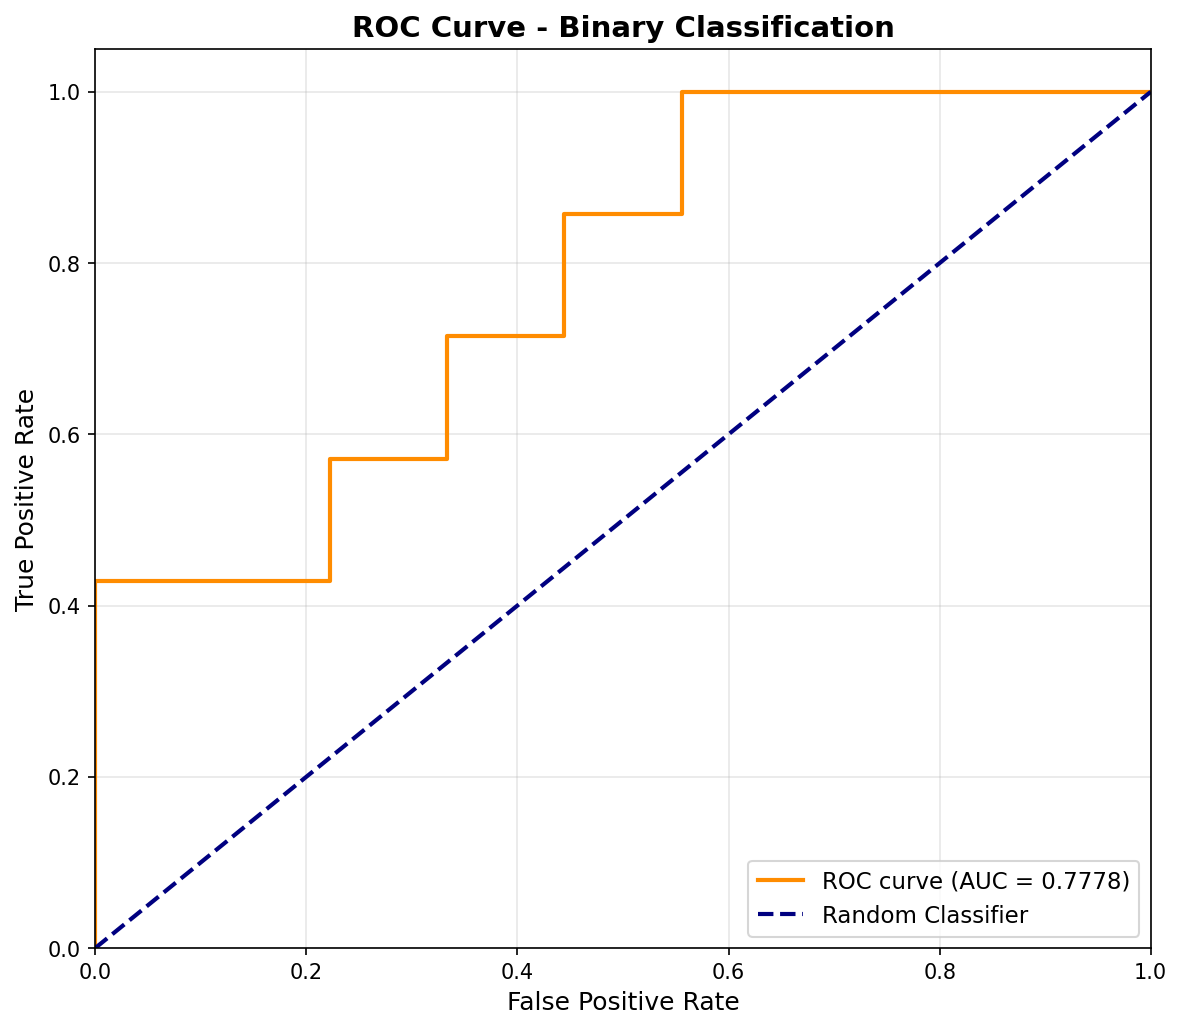

/kaggle/working/results/reports/baseline_aug1.0_drop0.3/confusion_matrix.png


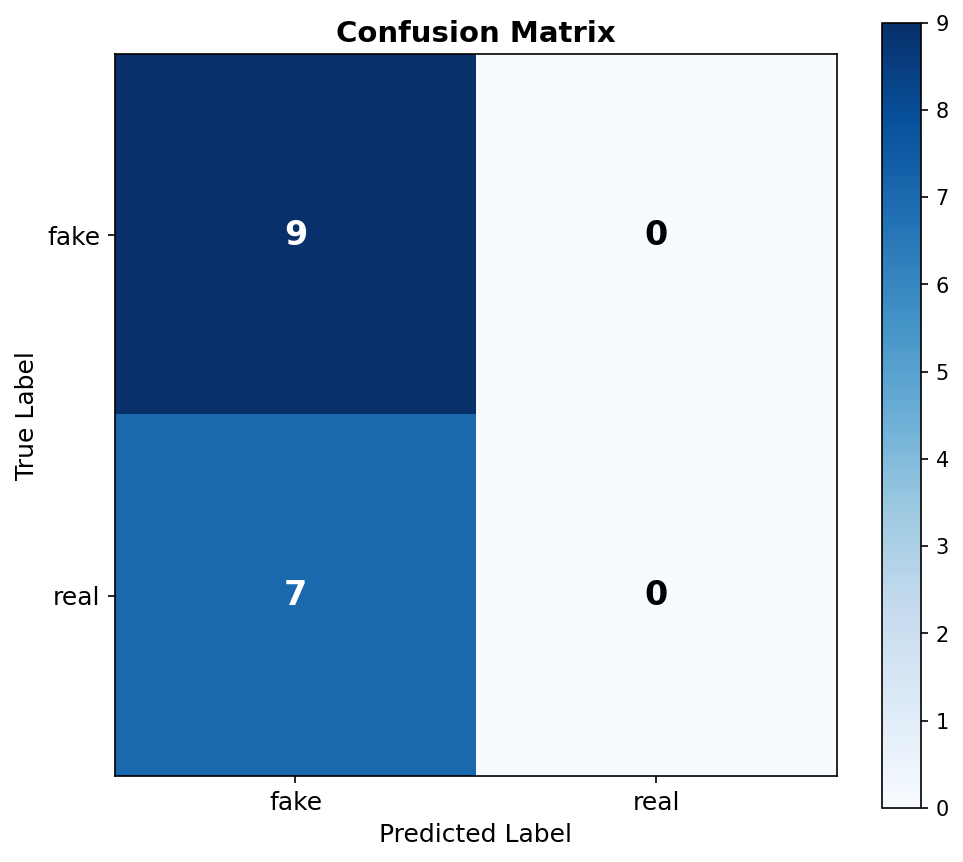

In [24]:
import csv
from pathlib import Path
from IPython.display import HTML, Image, display

csv_path = Path("/kaggle/working/results/experiments.csv")

with open(csv_path, newline="") as f:
    rows = list(csv.DictReader(f))

headers = rows[0].keys()

html = "<table border='1' style='border-collapse:collapse'>"
html += "<tr>" + "".join(f"<th style='padding:6px'>{h}</th>" for h in headers) + "</tr>"

for row in rows:
    html += "<tr>" + "".join(f"<td style='padding:6px'>{row[h]}</td>" for h in headers) + "</tr>"

html += "</table>"
display(HTML(html))

for img in Path("/kaggle/working/results/reports").glob("*/*.png"):
    print(img)
    display(Image(filename=str(img)))


In [26]:
!python scripts/run_experiments.py \
  --data_dir /kaggle/working/data \
  --time_budget_hours 2 \
  --batch_size 64 \
  --num_workers 2 \
  --architectures resnet18 \
  --augmentation_strengths 0.5 \
  --dropout_rates 0.5 \
  --epochs_resnet 3 \
  --patience 1


Using device: cuda
Experiment budget: 2.00 hours
Planned combinations: 1
Running: arch=resnet18, aug=0.5, drop=0.5
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
Starting training: arch=resnet18, aug=0.5, drop=0.5, epochs=3, lr=0.0003
Train:   5%|▊              | 40/750 [02:08<40:03,  3.38s/it, acc=61, loss=0.579]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Train:   6%|▊            | 44/750 [02:19<36:07,

architecture,augmentation_strength,dropout_rate,train_time_sec,final_val_loss,final_val_acc,final_precision,final_recall,final_f1,roc_auc,checkpoint_path,history_path,report_dir
baseline,0.5,0.3,1.81,0.6866341829299927,0.5625,0.28125,0.5,0.36,0.38095238095238093,/kaggle/working/results/baseline_aug0.5_drop0.3/best.pth,/kaggle/working/results/baseline_aug0.5_drop0.3/history.json,/kaggle/working/results/reports/baseline_aug0.5_drop0.3
baseline,1.0,0.3,0.09,0.6886512041091919,0.5625,0.28125,0.5,0.36,0.7777777777777778,/kaggle/working/results/baseline_aug1.0_drop0.3/best.pth,/kaggle/working/results/baseline_aug1.0_drop0.3/history.json,/kaggle/working/results/reports/baseline_aug1.0_drop0.3
resnet18,0.5,0.3,1.24,0.24706006050109863,1.0,1.0,1.0,1.0,1.0,/kaggle/working/results/resnet18_aug0.5_drop0.3/best.pth,/kaggle/working/results/resnet18_aug0.5_drop0.3/history.json,/kaggle/working/results/reports/resnet18_aug0.5_drop0.3
resnet18,1.0,0.3,0.95,0.19937214255332947,1.0,1.0,1.0,1.0,1.0,/kaggle/working/results/resnet18_aug1.0_drop0.3/best.pth,/kaggle/working/results/resnet18_aug1.0_drop0.3/history.json,/kaggle/working/results/reports/resnet18_aug1.0_drop0.3
resnet18,0.5,0.3,3128.76,0.5387784461391733,0.7319166666666667,0.7631470208930036,0.7319166666666667,0.7237194041193505,0.8435504444444445,/kaggle/working/results/resnet18_aug0.5_drop0.3/best.pth,/kaggle/working/results/resnet18_aug0.5_drop0.3/history.json,/kaggle/working/results/reports/resnet18_aug0.5_drop0.3
resnet18,0.5,0.5,6266.12,0.5269376172664317,0.74775,0.769792210993904,0.74775,0.742490320081115,0.841858111111111,/kaggle/working/results/resnet18_aug0.5_drop0.5/best.pth,/kaggle/working/results/resnet18_aug0.5_drop0.5/history.json,/kaggle/working/results/reports/resnet18_aug0.5_drop0.5


/kaggle/working/results/reports/resnet18_aug0.5_drop0.3/roc_curve.png


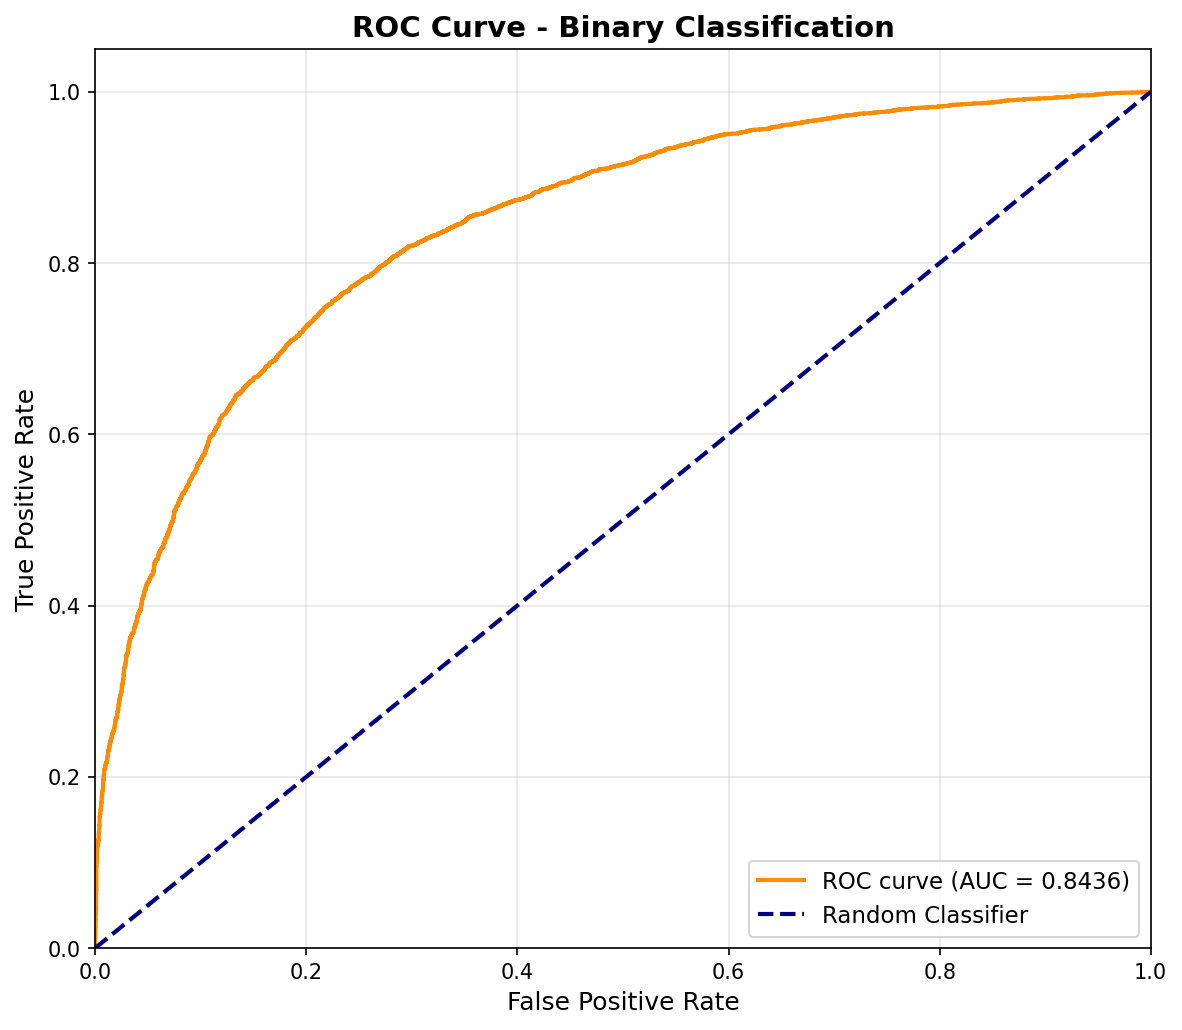

/kaggle/working/results/reports/resnet18_aug0.5_drop0.3/confusion_matrix.png


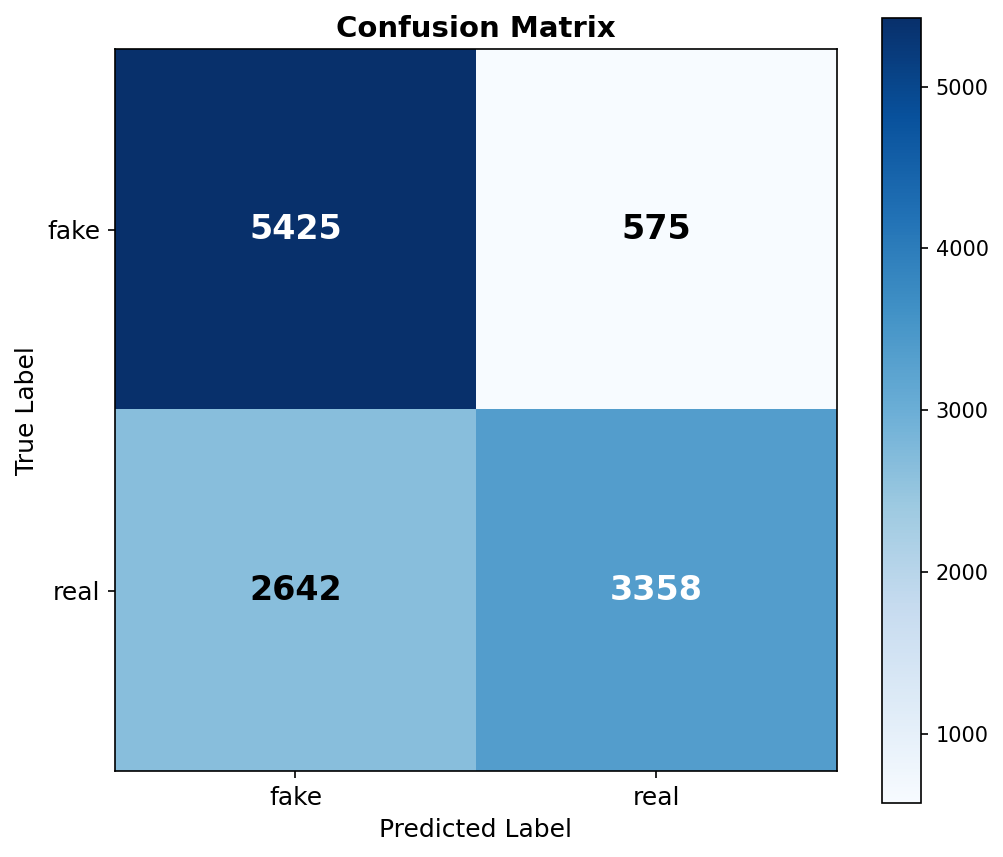

/kaggle/working/results/reports/baseline_aug0.5_drop0.3/roc_curve.png


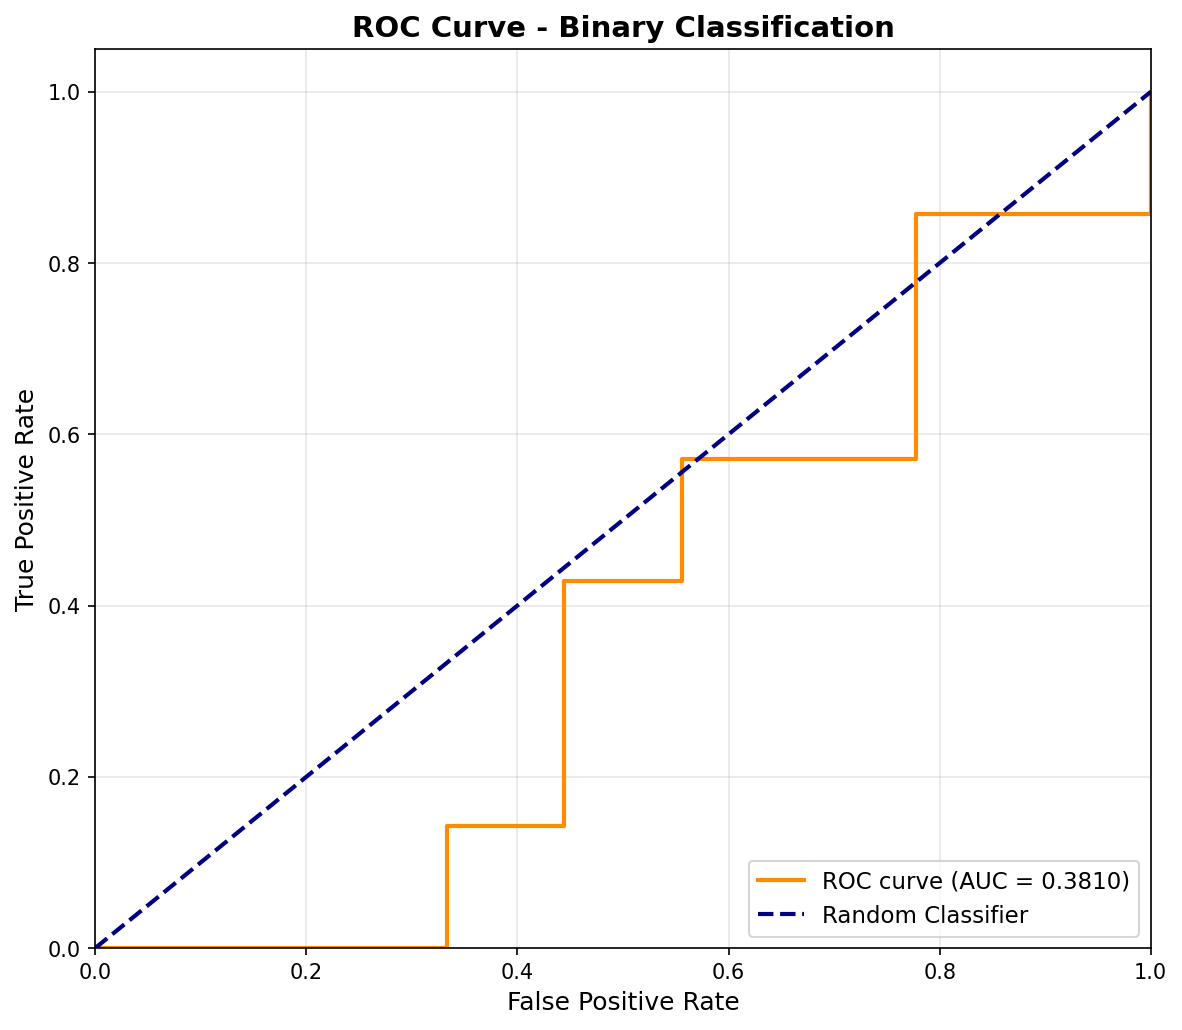

/kaggle/working/results/reports/baseline_aug0.5_drop0.3/confusion_matrix.png


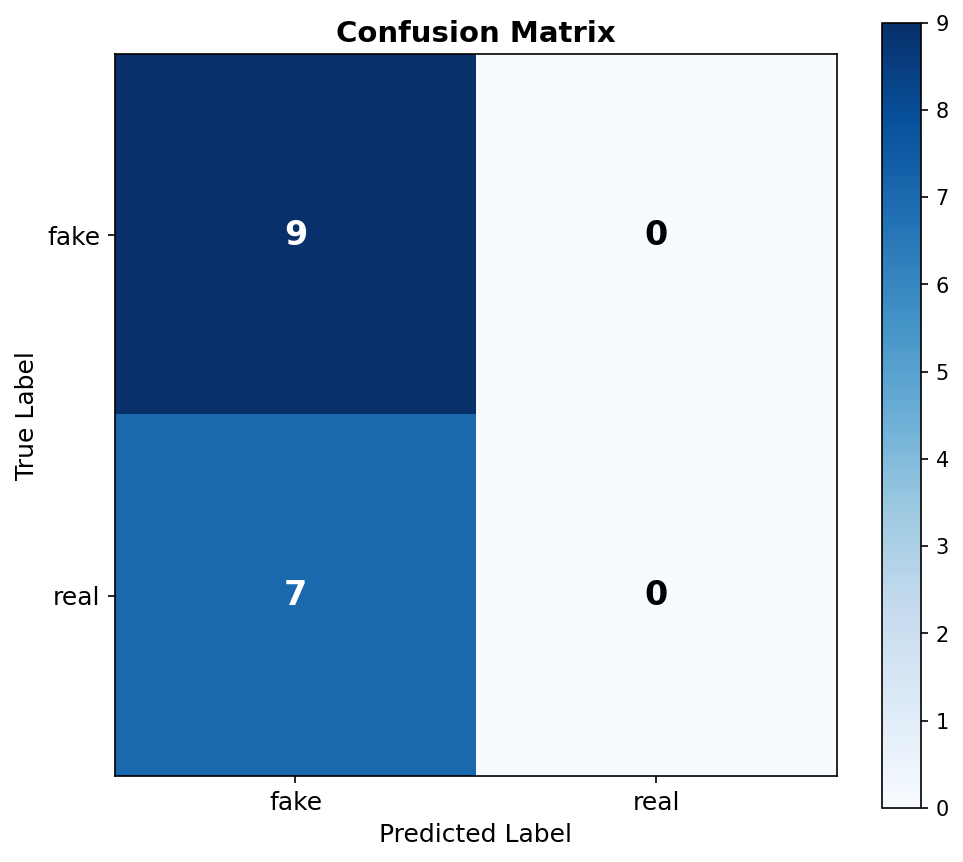

/kaggle/working/results/reports/resnet18_aug0.5_drop0.5/roc_curve.png


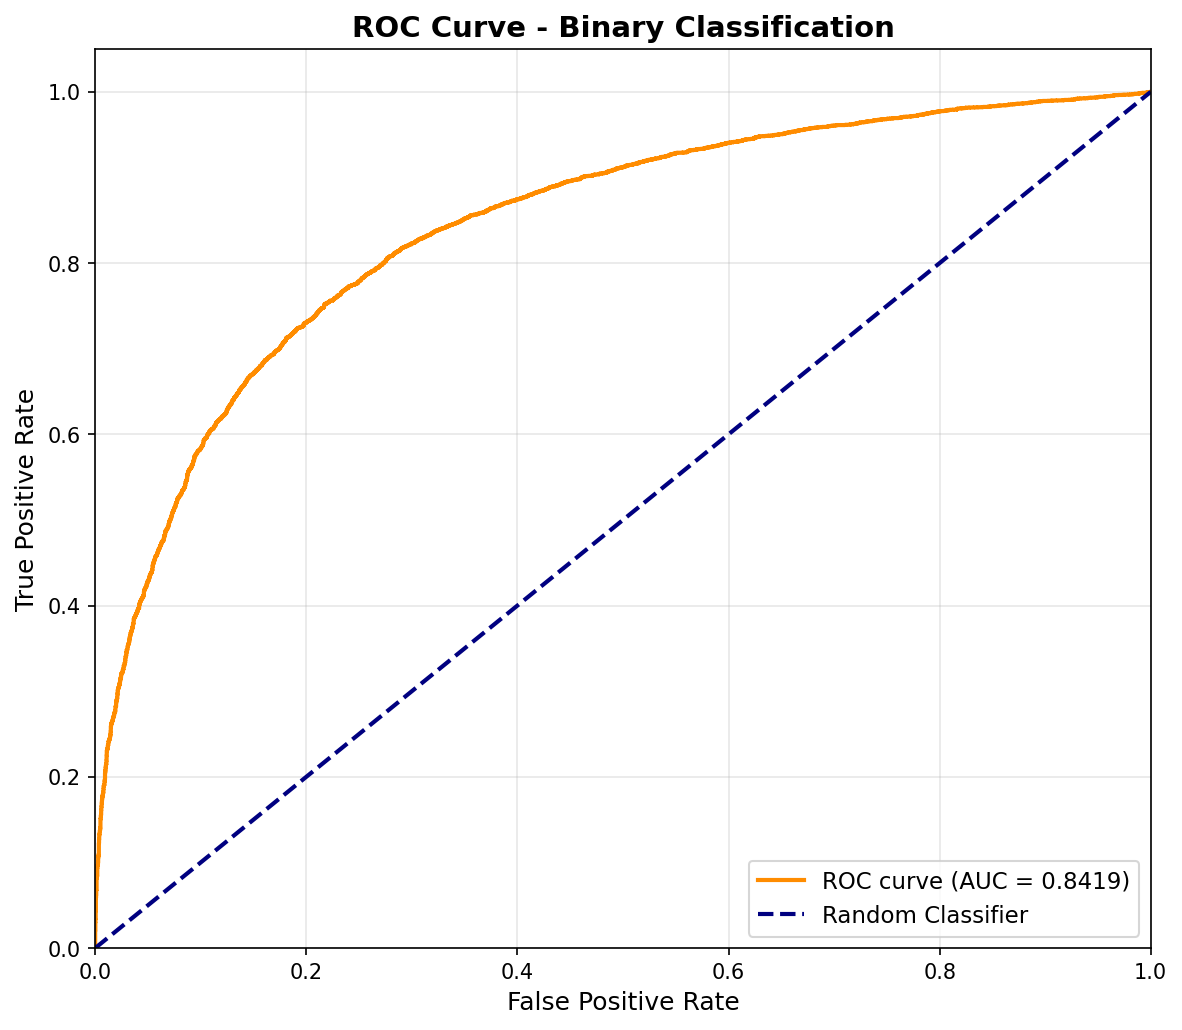

/kaggle/working/results/reports/resnet18_aug0.5_drop0.5/confusion_matrix.png


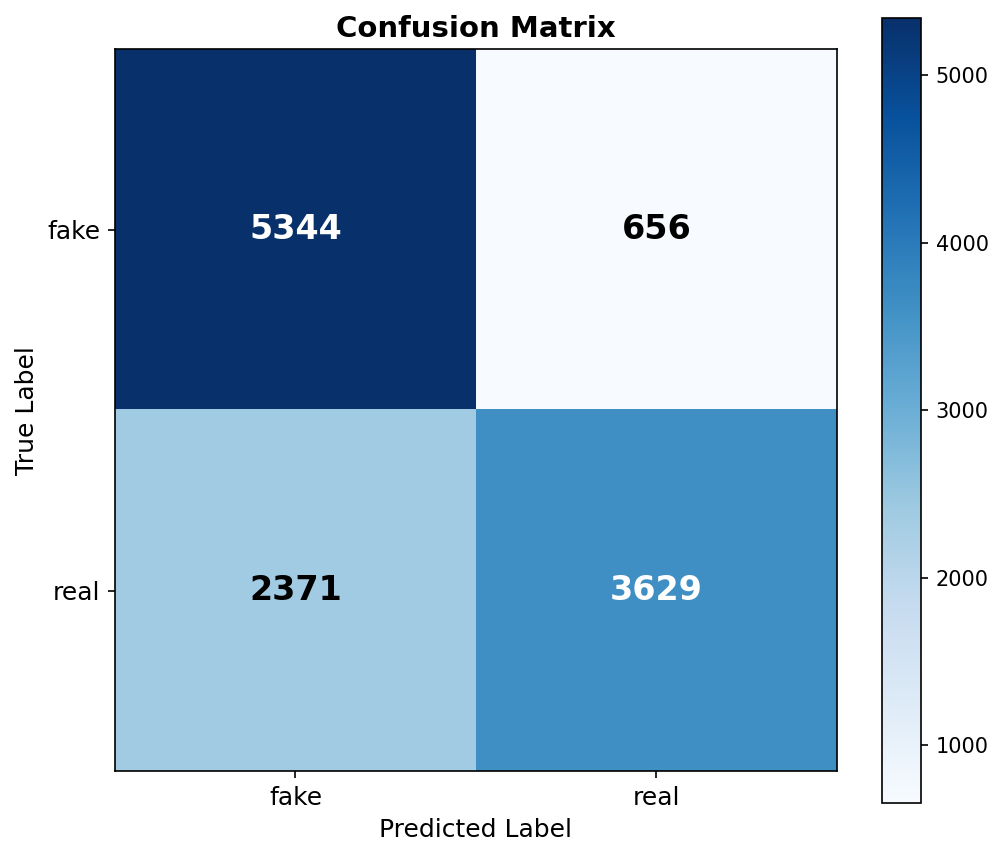

/kaggle/working/results/reports/resnet18_aug1.0_drop0.3/roc_curve.png


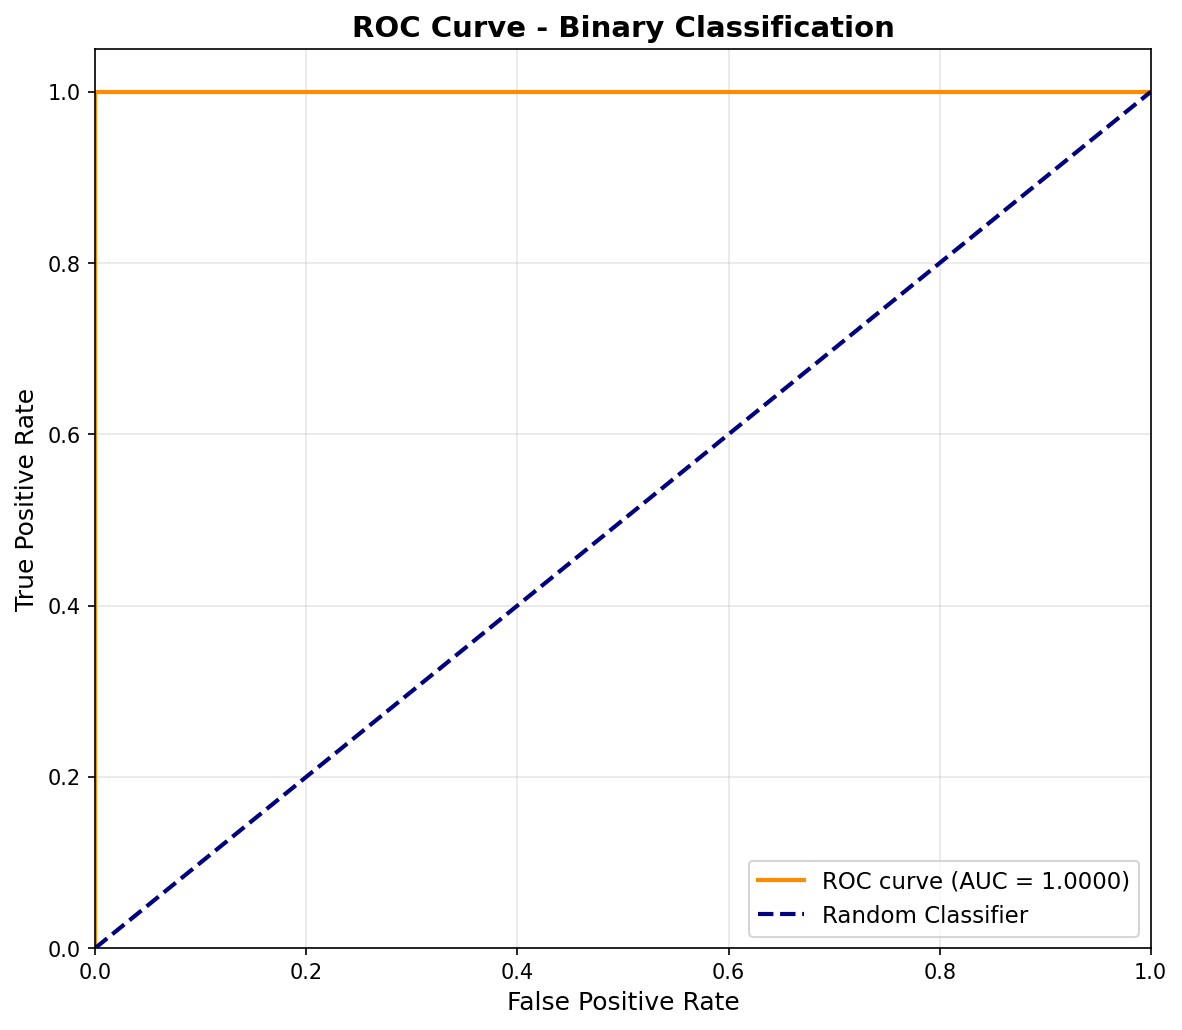

/kaggle/working/results/reports/resnet18_aug1.0_drop0.3/confusion_matrix.png


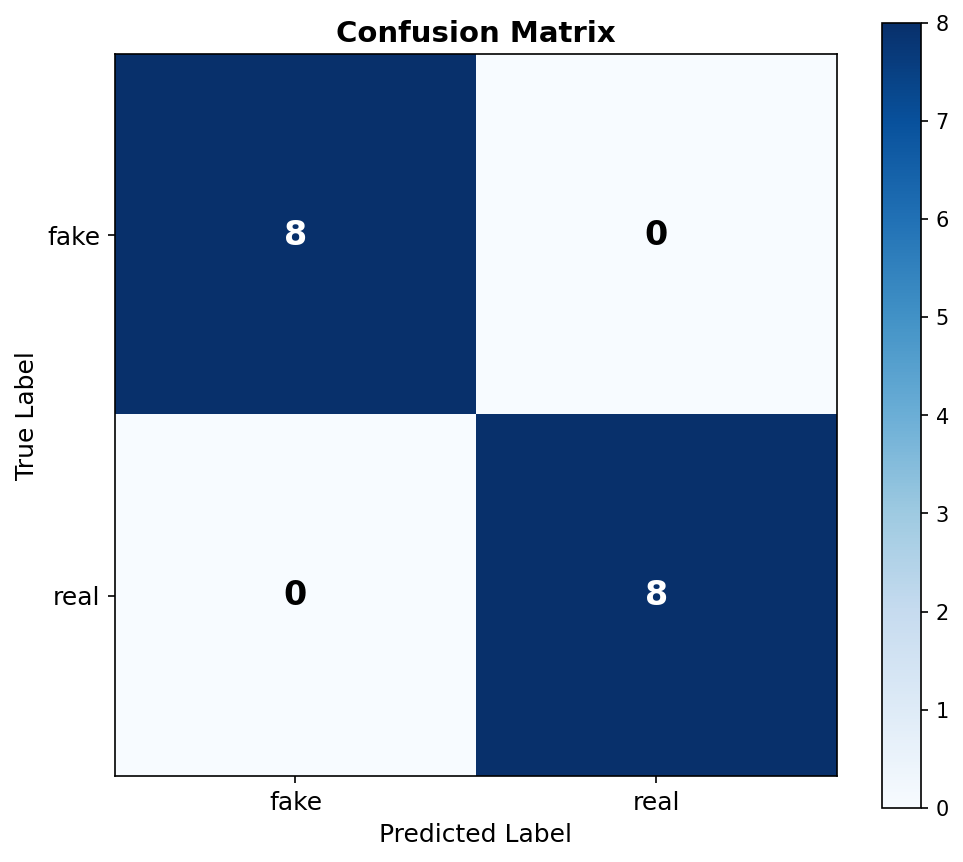

/kaggle/working/results/reports/baseline_aug1.0_drop0.3/roc_curve.png


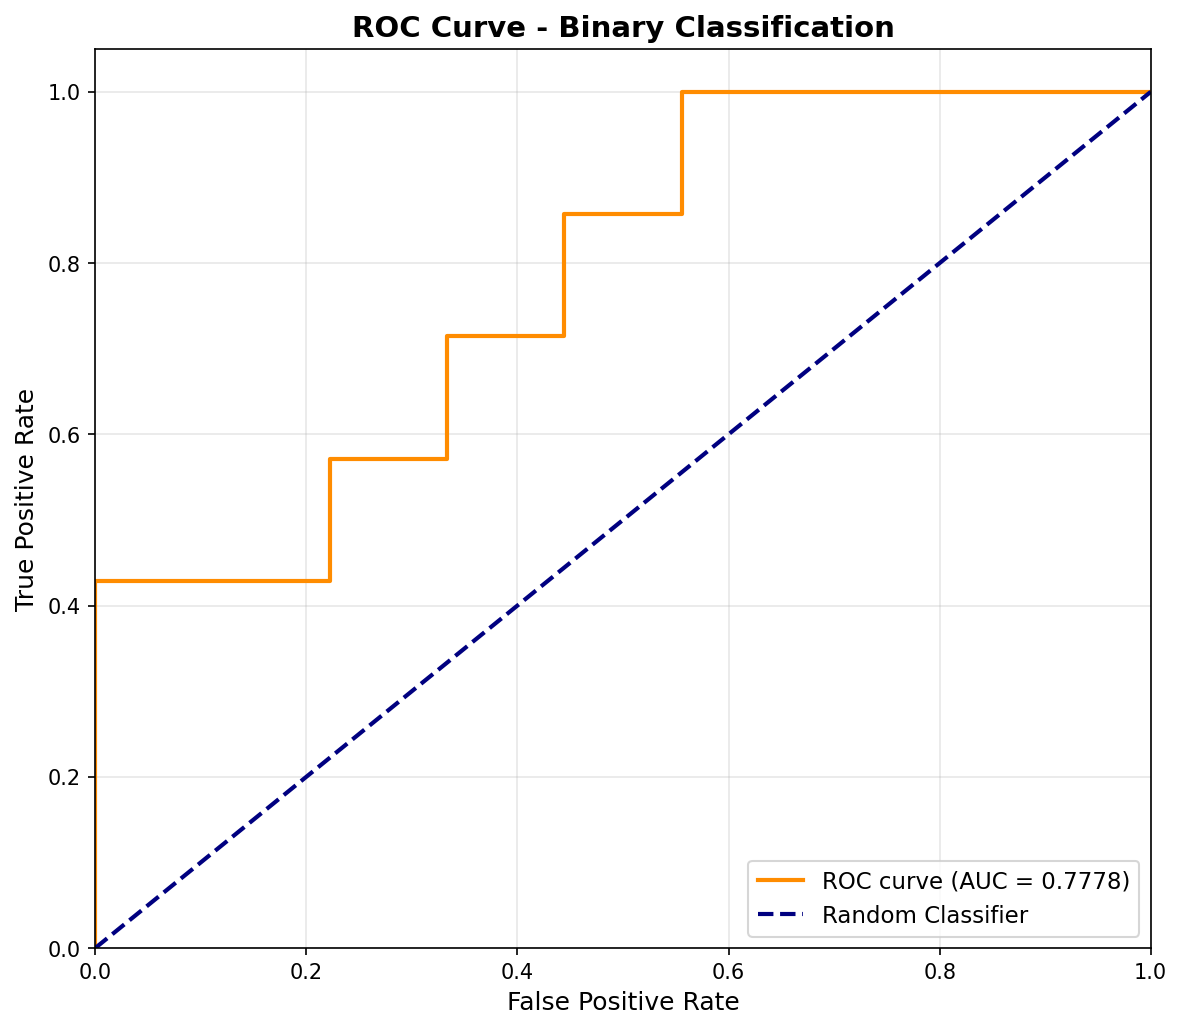

/kaggle/working/results/reports/baseline_aug1.0_drop0.3/confusion_matrix.png


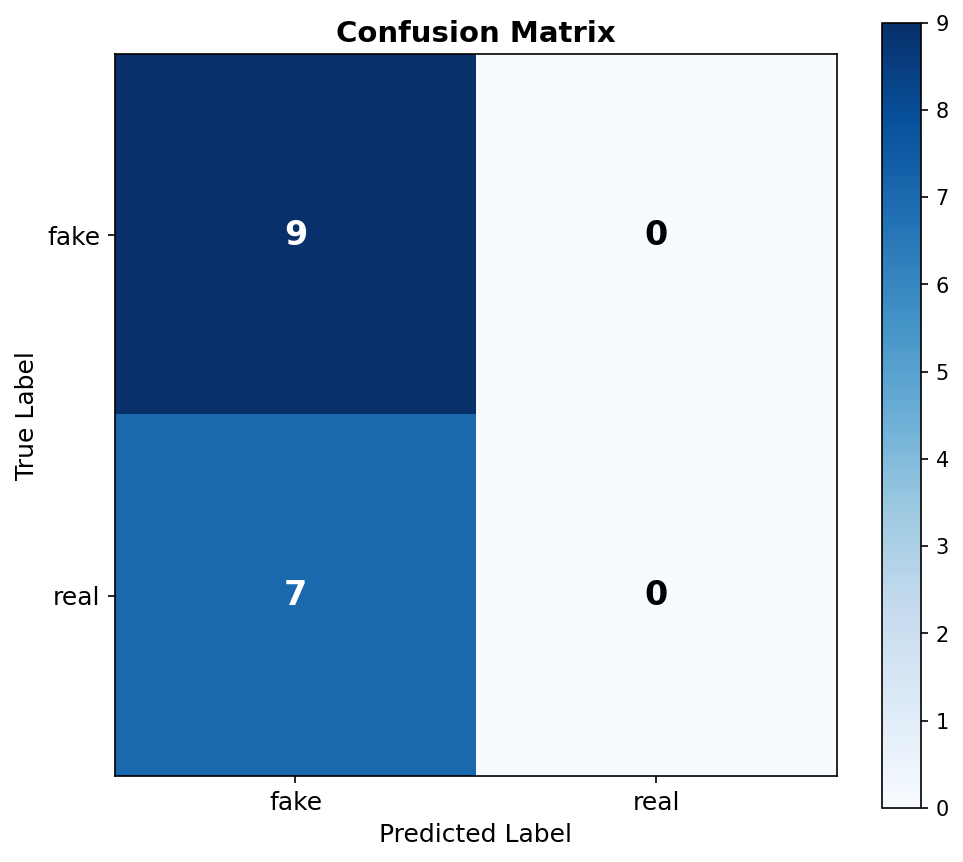

In [27]:
import csv
from pathlib import Path
from IPython.display import HTML, Image, display

csv_path = Path("/kaggle/working/results/experiments.csv")

with open(csv_path, newline="") as f:
    rows = list(csv.DictReader(f))

headers = rows[0].keys()

html = "<table border='1' style='border-collapse:collapse'>"
html += "<tr>" + "".join(f"<th style='padding:6px'>{h}</th>" for h in headers) + "</tr>"

for row in rows:
    html += "<tr>" + "".join(f"<td style='padding:6px'>{row[h]}</td>" for h in headers) + "</tr>"

html += "</table>"
display(HTML(html))

for img in Path("/kaggle/working/results/reports").glob("*/*.png"):
    print(img)
    display(Image(filename=str(img)))


In [28]:
!cat /kaggle/working/results/experiments.csv


architecture,augmentation_strength,dropout_rate,train_time_sec,final_val_loss,final_val_acc,final_precision,final_recall,final_f1,roc_auc,checkpoint_path,history_path,report_dir
baseline,0.5,0.3,1.81,0.6866341829299927,0.5625,0.28125,0.5,0.36,0.38095238095238093,/kaggle/working/results/baseline_aug0.5_drop0.3/best.pth,/kaggle/working/results/baseline_aug0.5_drop0.3/history.json,/kaggle/working/results/reports/baseline_aug0.5_drop0.3
baseline,1.0,0.3,0.09,0.6886512041091919,0.5625,0.28125,0.5,0.36,0.7777777777777778,/kaggle/working/results/baseline_aug1.0_drop0.3/best.pth,/kaggle/working/results/baseline_aug1.0_drop0.3/history.json,/kaggle/working/results/reports/baseline_aug1.0_drop0.3
resnet18,0.5,0.3,1.24,0.24706006050109863,1.0,1.0,1.0,1.0,1.0,/kaggle/working/results/resnet18_aug0.5_drop0.3/best.pth,/kaggle/working/results/resnet18_aug0.5_drop0.3/history.json,/kaggle/working/results/reports/resnet18_aug0.5_drop0.3
resnet18,1.0,0.3,0.95,0.19937214255332947,1.0,1.0,1.0,1.0,1.0,/kaggle

In [ ]:
!python scripts/run_experiments.py \
  --data_dir /kaggle/working/data \
  --time_budget_hours 2 \
  --batch_size 64 \
  --num_workers 2 \
  --architectures baseline \
  --augmentation_strengths 0.5 \
  --dropout_rates 0.3 \
  --epochs_baseline 2 \
  --patience 1


In [29]:
!ls -lh /kaggle/working/results/baseline_aug0.5_drop0.3


total 4.9M
-rw-r--r-- 1 root root 4.9M May  5 13:49 best.pth
-rw-r--r-- 1 root root  244 May  5 14:41 history.json


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (143040000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (121554000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Baseline real checkpoint
val_loss: 0.565093430829175
accuracy: 0.7101666666666666
precision: 0.713685955641665
recall: 0.7101666666666666
f1: 0.7089683844105347
roc_auc: 0.7910494722222222
confusion matrix:
[[3876 2124]
 [1354 4646]]


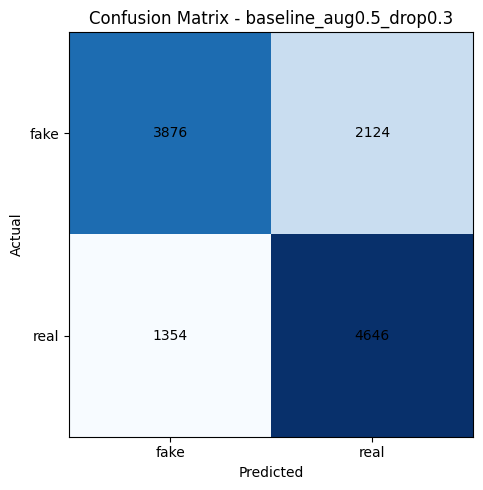

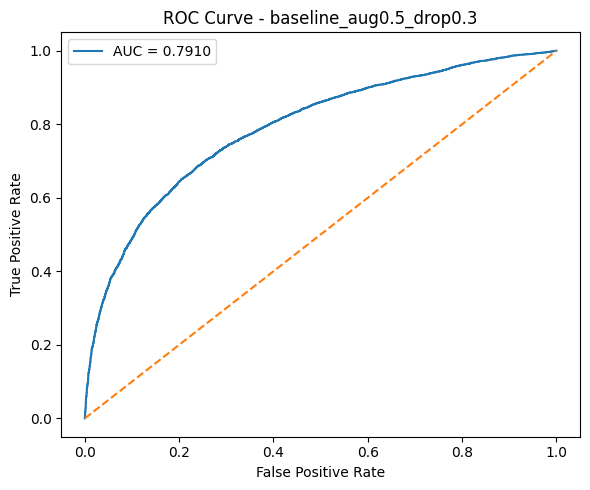

In [33]:
import sys, csv, json, torch
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

sys.path.insert(0, "/kaggle/working/cnn-ai-image-generalization")

from src.model import get_model
from src.dataset import get_dataloaders

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

_, val_loader, class_names = get_dataloaders(
    data_dir="/kaggle/working/data",
    batch_size=64,
    image_size=128,
    num_workers=2,
    augmentation_strength=0.5,
)

model = get_model(architecture="baseline", dropout_rate=0.3)
ckpt = torch.load("/kaggle/working/results/baseline_aug0.5_drop0.3/best.pth", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)
model.eval()

criterion = torch.nn.CrossEntropyLoss()
losses, y_true, y_pred, y_score = [], [], [], []

with torch.no_grad():
    for x, y in val_loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        loss = criterion(out, y)
        probs = torch.softmax(out, dim=1)
        losses.append(loss.item())
        y_true.extend(y.cpu().numpy())
        y_pred.extend(out.argmax(1).cpu().numpy())
        y_score.extend(probs[:, 1].cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_score = np.array(y_score)

cm = np.zeros((2, 2), dtype=int)
for t, p in zip(y_true, y_pred):
    cm[t, p] += 1

acc = (y_true == y_pred).mean()
precision, recall, f1s = [], [], []
for c in [0, 1]:
    tp = cm[c, c]
    fp = cm[:, c].sum() - tp
    fn = cm[c, :].sum() - tp
    p = tp / (tp + fp) if tp + fp else 0
    r = tp / (tp + fn) if tp + fn else 0
    f = 2 * p * r / (p + r) if p + r else 0
    precision.append(p); recall.append(r); f1s.append(f)

macro_precision = float(np.mean(precision))
macro_recall = float(np.mean(recall))
macro_f1 = float(np.mean(f1s))
val_loss = float(np.mean(losses))

# AUC by rank statistic
pos = y_true == 1
neg = y_true == 0
order = np.argsort(y_score)
ranks = np.empty_like(order, dtype=float)
ranks[order] = np.arange(1, len(y_score) + 1)
roc_auc = (ranks[pos].sum() - pos.sum() * (pos.sum() + 1) / 2) / (pos.sum() * neg.sum())

print("Baseline real checkpoint")
print("val_loss:", val_loss)
print("accuracy:", acc)
print("precision:", macro_precision)
print("recall:", macro_recall)
print("f1:", macro_f1)
print("roc_auc:", roc_auc)
print("confusion matrix:")
print(cm)

report_dir = Path("/kaggle/working/results/reports/baseline_aug0.5_drop0.3")
report_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.xticks([0, 1], class_names)
plt.yticks([0, 1], class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - baseline_aug0.5_drop0.3")
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")
plt.tight_layout()
plt.savefig(report_dir / "confusion_matrix.png", dpi=150)
plt.show()

thresholds = np.r_[np.inf, np.sort(np.unique(y_score))[::-1]]
tpr, fpr = [], []
for th in thresholds:
    pred_pos = y_score >= th
    tp = np.logical_and(pred_pos, pos).sum()
    fp = np.logical_and(pred_pos, neg).sum()
    tpr.append(tp / pos.sum())
    fpr.append(fp / neg.sum())

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - baseline_aug0.5_drop0.3")
plt.legend()
plt.tight_layout()
plt.savefig(report_dir / "roc_curve.png", dpi=150)
plt.show()


In [35]:
csv_path = Path("/kaggle/working/results/experiments.csv")

with open(csv_path, "a", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "baseline", 0.5, 0.3, "",
        val_loss, acc, macro_precision, macro_recall, macro_f1, roc_auc,
        "/kaggle/working/results/baseline_aug0.5_drop0.3/best.pth",
        "/kaggle/working/results/baseline_aug0.5_drop0.3/history.json",
        str(report_dir),
    ])


PROJECT SUMMARY
Task: binary classification of real vs AI-generated images.
Dataset: Kaggle AI-Generated Images vs Real Images.
Models used: baseline CNN and ResNet-18.
Input size: 128x128 RGB images.
Training: Adam optimizer, cross-entropy loss, early stopping on validation macro-F1.
Reports saved: experiments.csv, checkpoints, confusion matrices, ROC curves.

IGNORED DUMMY/SMOKE ROWS: 4
REAL RUNS USED FOR REPORT: 3



architecture,augmentation_strength,dropout_rate,final_val_acc,final_precision,final_recall,final_f1,roc_auc,train_time_sec
resnet18,0.5000,0.3000,0.7319,0.7631,0.7319,0.7237,0.8436,3128.7600
resnet18,0.5000,0.5000,0.7478,0.7698,0.7478,0.7425,0.8419,6266.1200
baseline,0.5000,0.3000,0.7102,0.7137,0.7102,0.7090,0.7910,


BEST RUN BY F1
Architecture: resnet18
Augmentation strength: 0.5
Dropout: 0.5
Accuracy: 0.7478
F1: 0.7425
ROC-AUC: 0.8419

FIGURES
/kaggle/working/results/reports/baseline_aug0.5_drop0.3/confusion_matrix.png


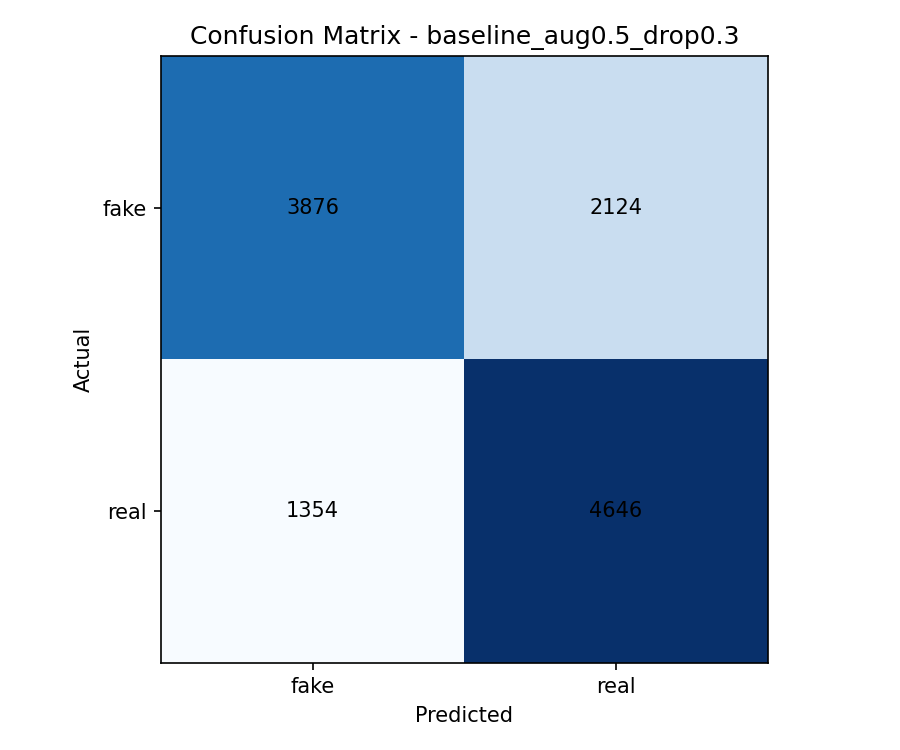

/kaggle/working/results/reports/baseline_aug0.5_drop0.3/roc_curve.png


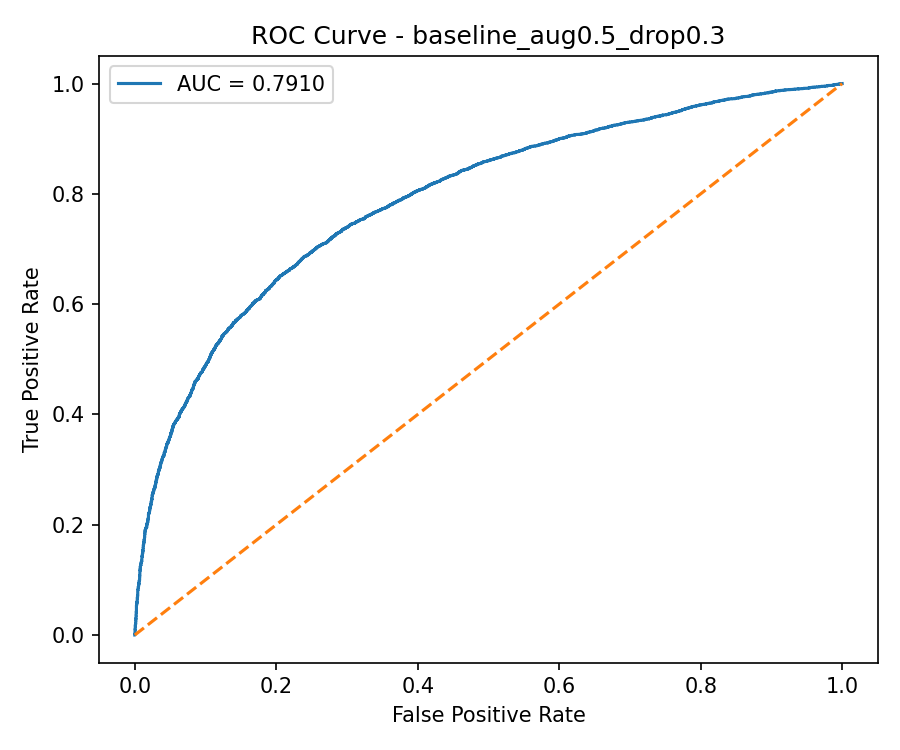

/kaggle/working/results/reports/baseline_aug1.0_drop0.3/confusion_matrix.png


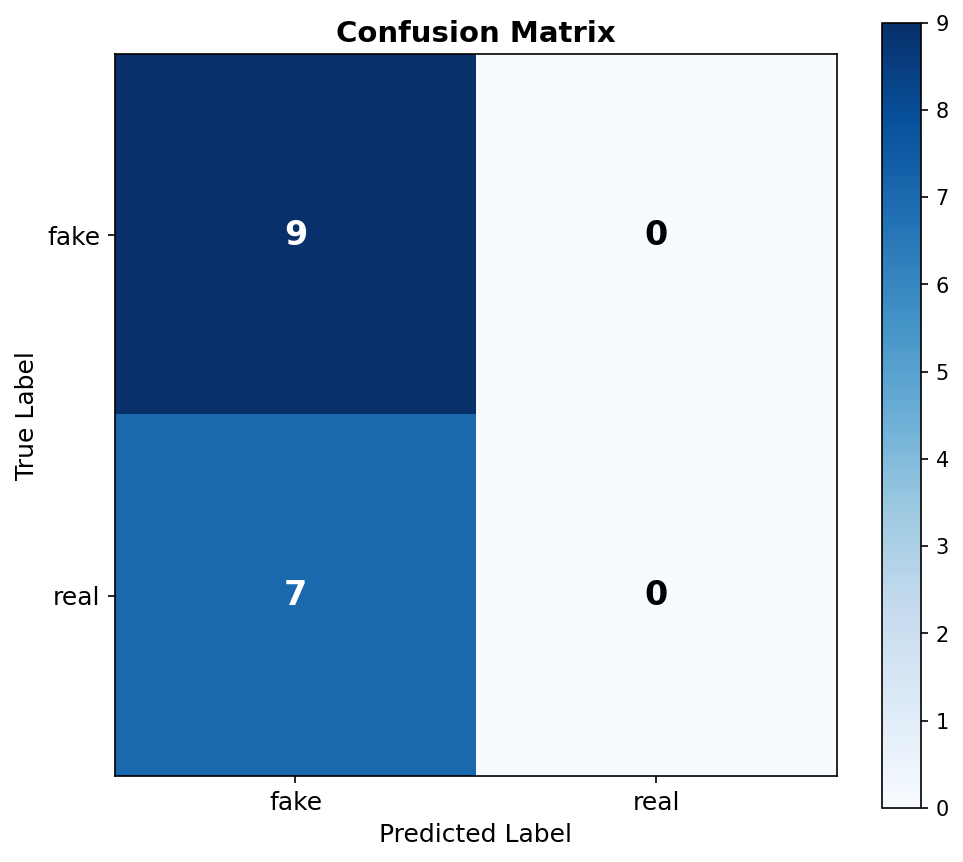

/kaggle/working/results/reports/baseline_aug1.0_drop0.3/roc_curve.png


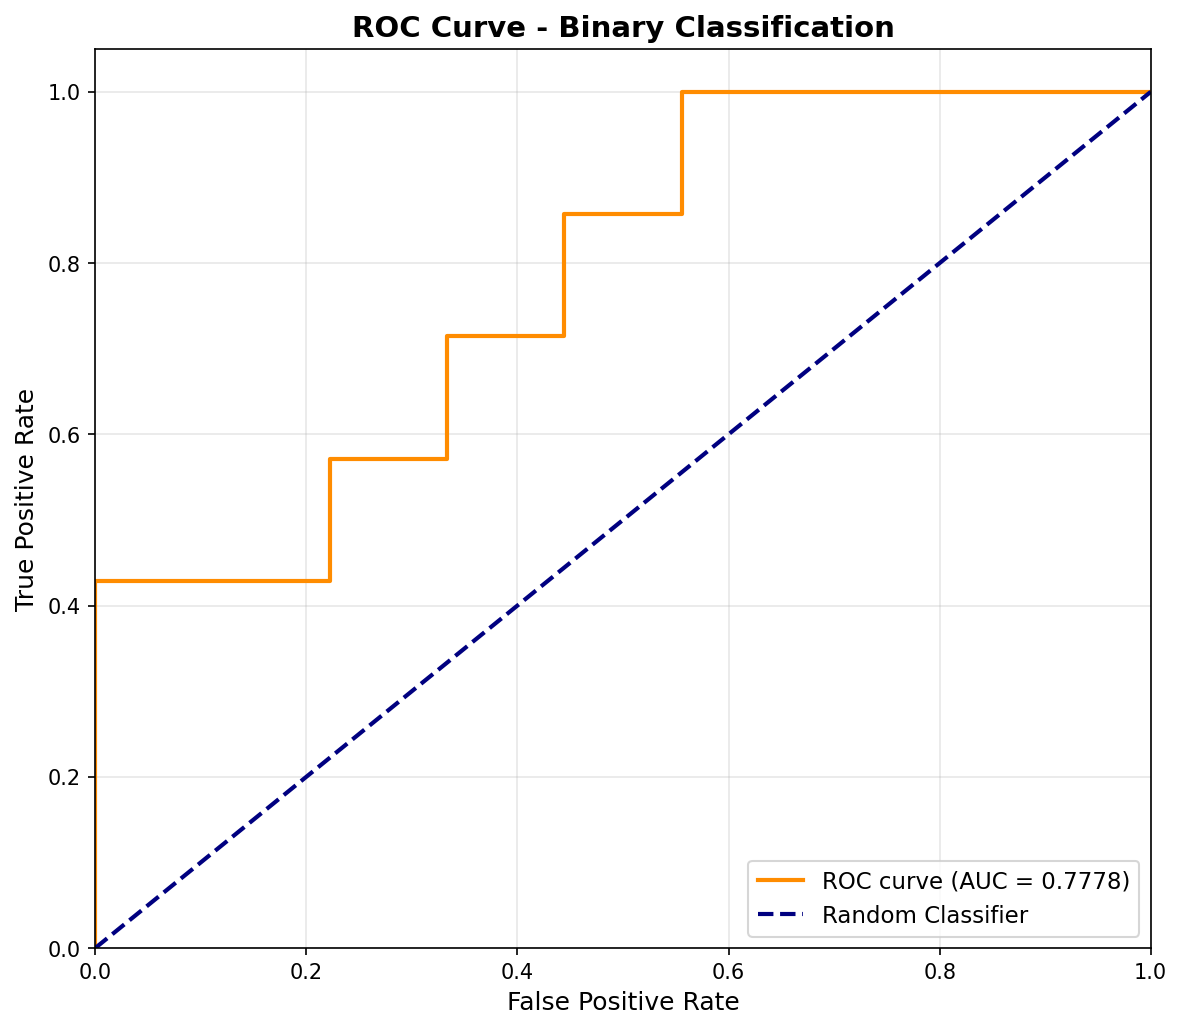

/kaggle/working/results/reports/resnet18_aug0.5_drop0.3/confusion_matrix.png


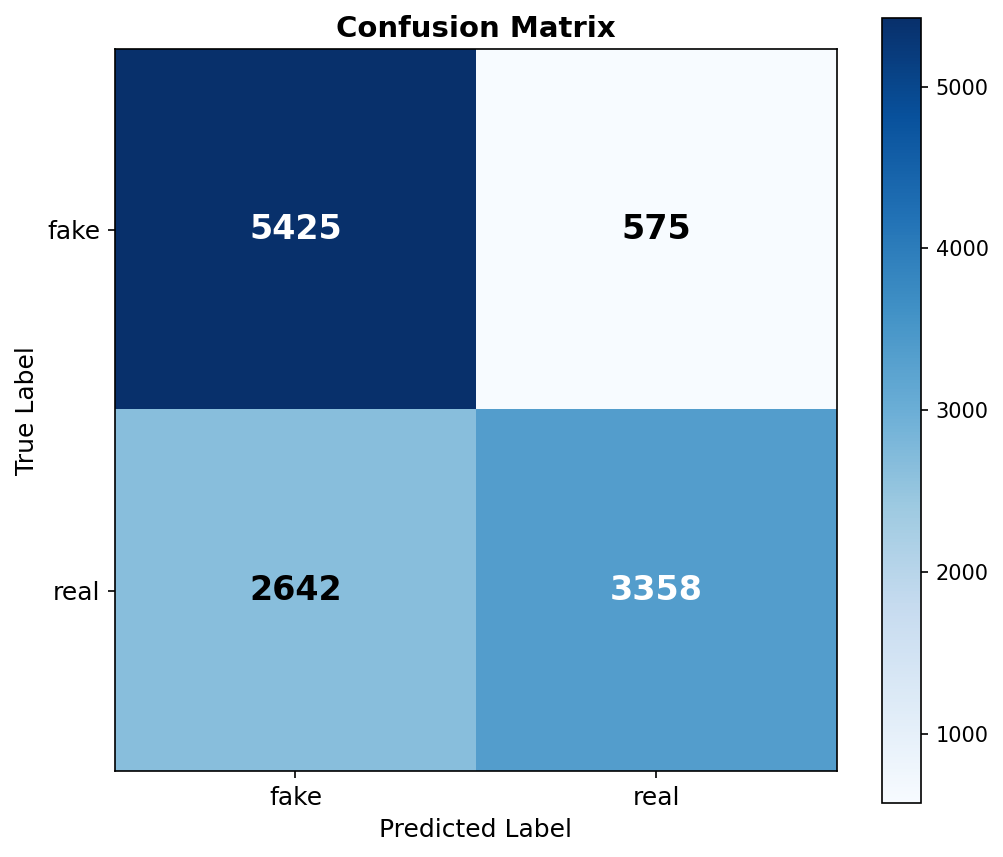

/kaggle/working/results/reports/resnet18_aug0.5_drop0.3/roc_curve.png


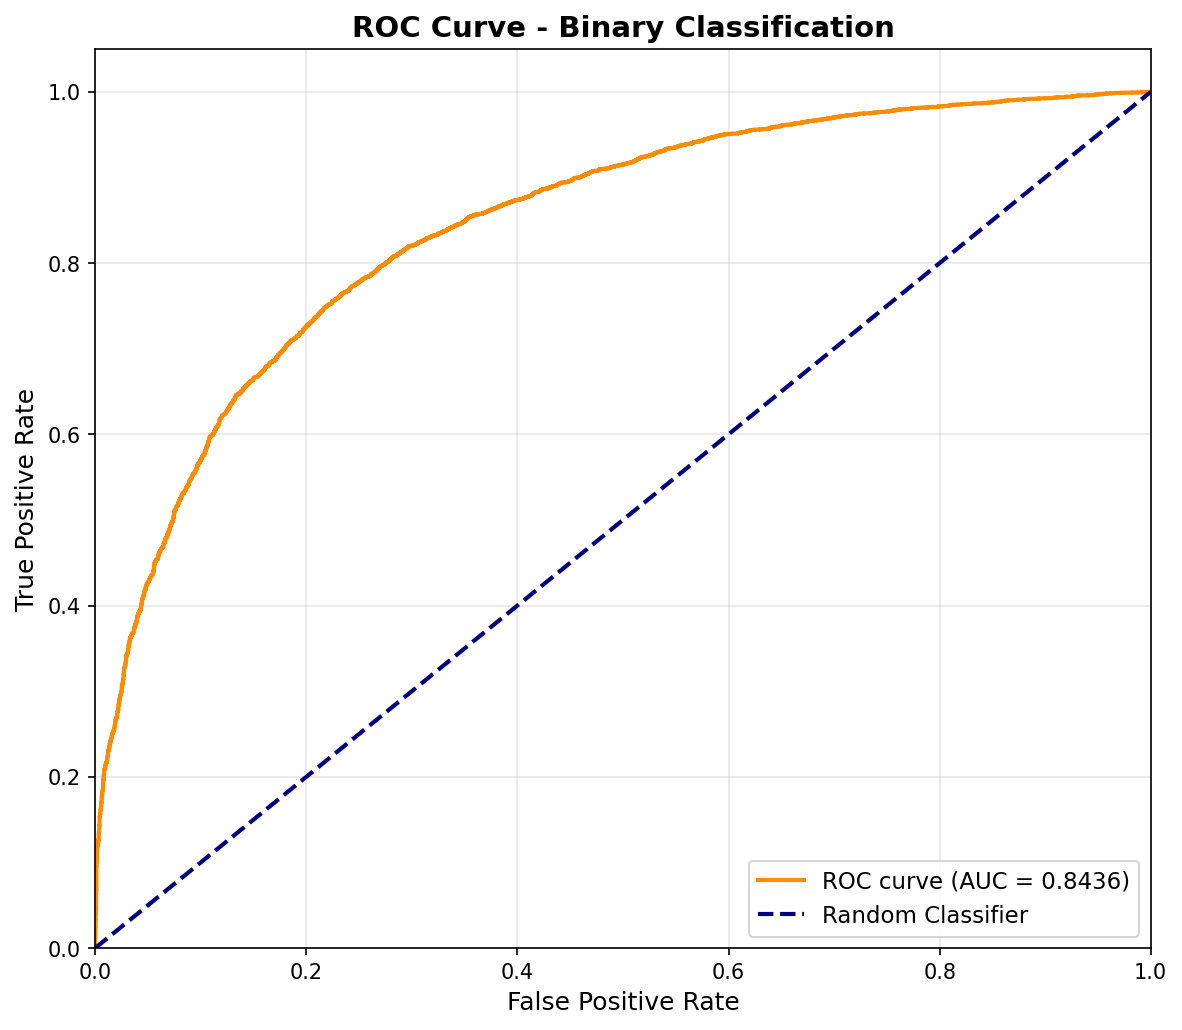

/kaggle/working/results/reports/resnet18_aug0.5_drop0.5/confusion_matrix.png


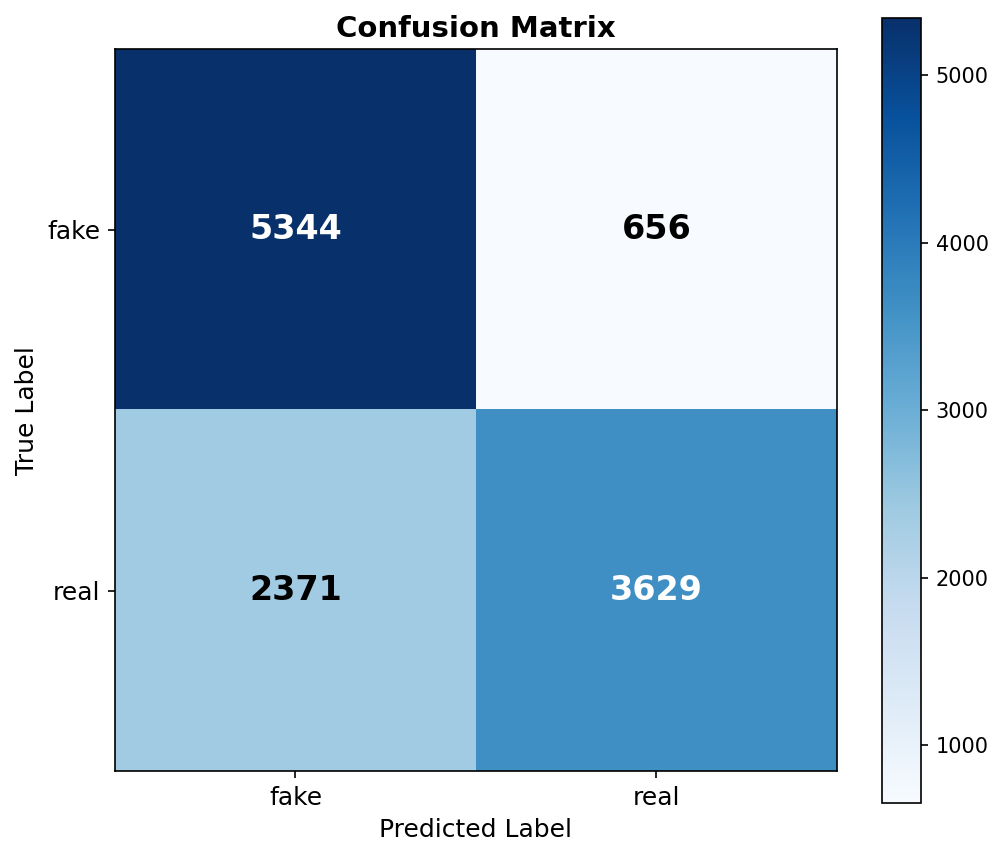

/kaggle/working/results/reports/resnet18_aug0.5_drop0.5/roc_curve.png


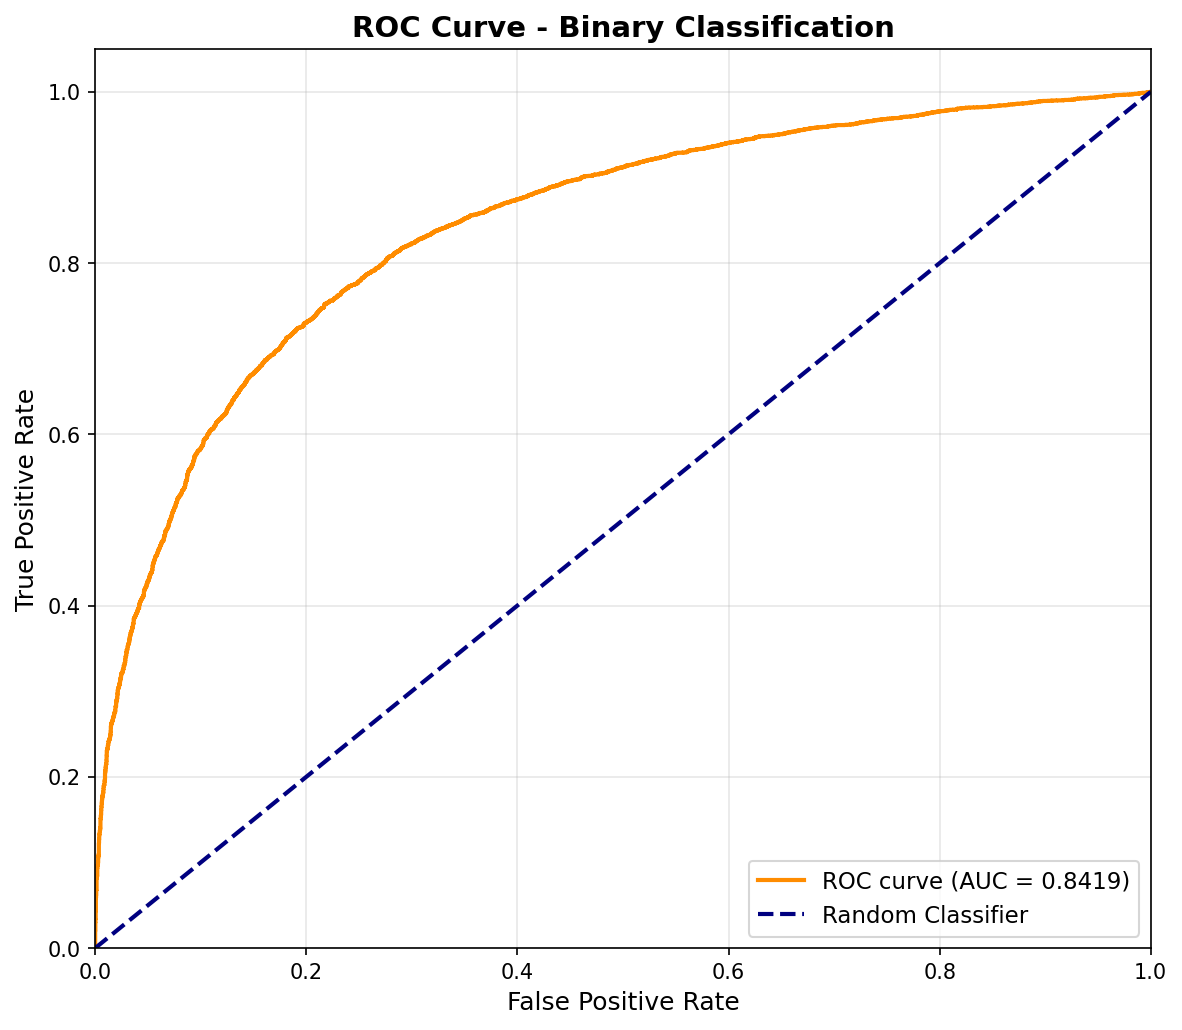

/kaggle/working/results/reports/resnet18_aug1.0_drop0.3/confusion_matrix.png


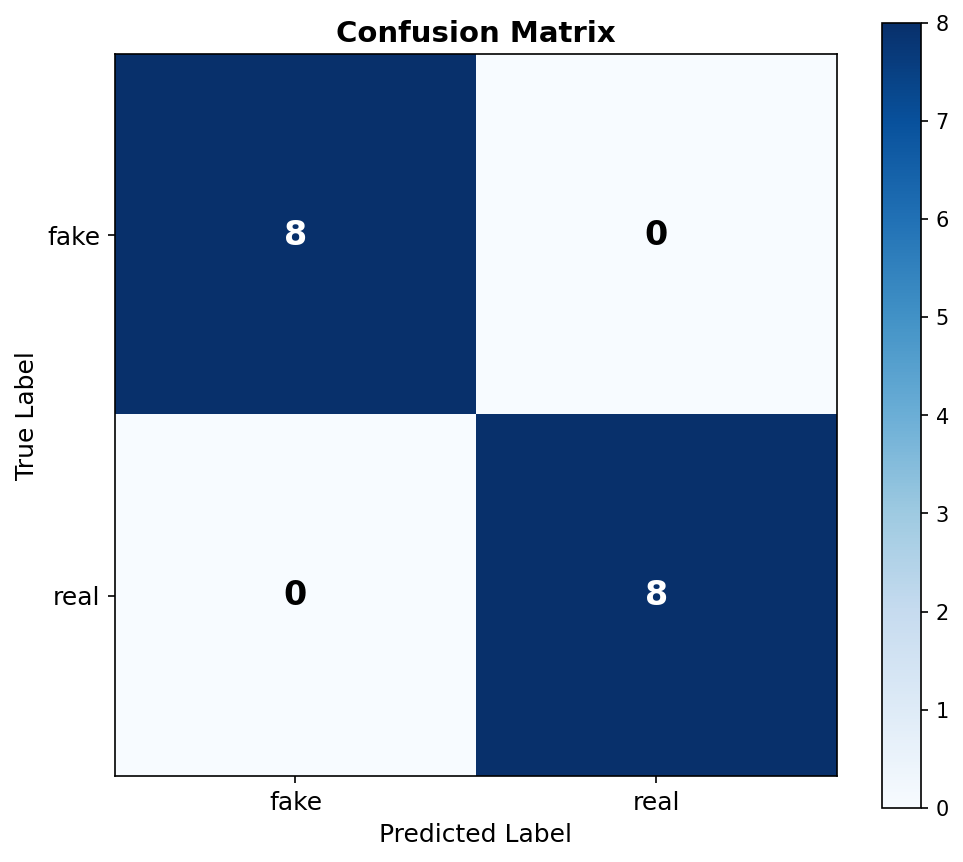

/kaggle/working/results/reports/resnet18_aug1.0_drop0.3/roc_curve.png


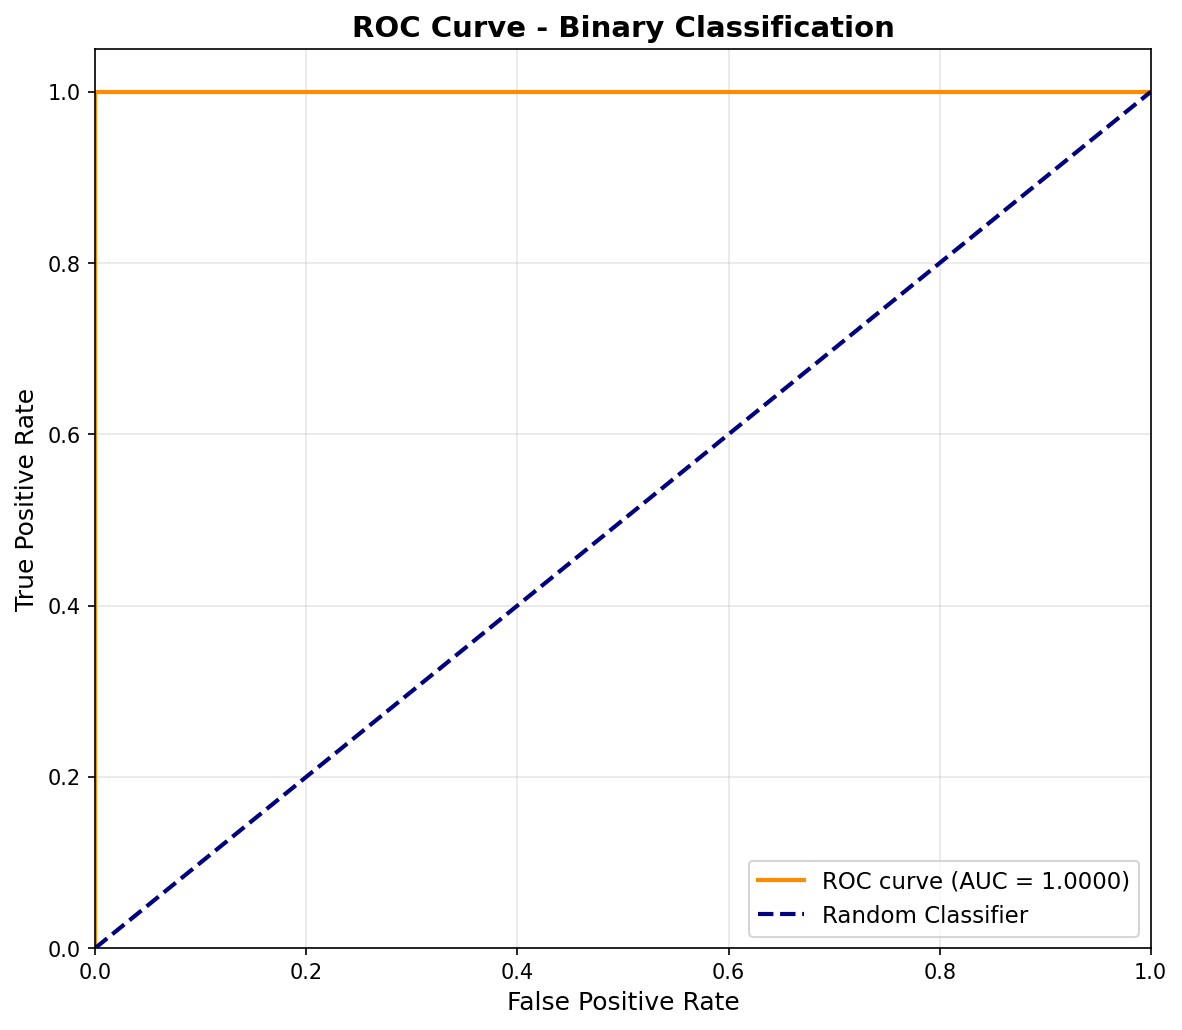

Saved:
/kaggle/working/results/final_report.md
/kaggle/working/results/final_report.html


In [36]:
import csv, json, os
from pathlib import Path
from html import escape
from IPython.display import HTML, Image, display

RESULTS_DIR = Path("/kaggle/working/results")
CSV_PATH = RESULTS_DIR / "experiments.csv"
REPORT_OUT = RESULTS_DIR / "final_report.md"
HTML_OUT = RESULTS_DIR / "final_report.html"

def to_float(x):
    try:
        return float(x)
    except Exception:
        return None

def is_real_run(row):
    t = to_float(row.get("train_time_sec", ""))
    # Dummy/smoke rows took only seconds. Real Kaggle runs took thousands of seconds.
    return t is None or t >= 600

with open(CSV_PATH, newline="") as f:
    rows = list(csv.DictReader(f))

real_rows = [r for r in rows if is_real_run(r)]
dummy_rows = [r for r in rows if not is_real_run(r)]

# Keep the latest/biggest real result for each config.
best_by_config = {}
for r in real_rows:
    key = (r["architecture"], r["augmentation_strength"], r["dropout_rate"])
    old = best_by_config.get(key)
    if old is None:
        best_by_config[key] = r
    else:
        old_t = to_float(old.get("train_time_sec", "")) or 0
        new_t = to_float(r.get("train_time_sec", "")) or 0
        if new_t >= old_t:
            best_by_config[key] = r

real_rows = list(best_by_config.values())

metric_cols = [
    "architecture", "augmentation_strength", "dropout_rate",
    "final_val_acc", "final_precision", "final_recall", "final_f1", "roc_auc",
    "train_time_sec"
]

def fmt(x):
    v = to_float(x)
    if v is None:
        return str(x)
    return f"{v:.4f}"

print("PROJECT SUMMARY")
print("=" * 70)
print("Task: binary classification of real vs AI-generated images.")
print("Dataset: Kaggle AI-Generated Images vs Real Images.")
print("Models used: baseline CNN and ResNet-18.")
print("Input size: 128x128 RGB images.")
print("Training: Adam optimizer, cross-entropy loss, early stopping on validation macro-F1.")
print("Reports saved: experiments.csv, checkpoints, confusion matrices, ROC curves.")
print()

print("IGNORED DUMMY/SMOKE ROWS:", len(dummy_rows))
print("REAL RUNS USED FOR REPORT:", len(real_rows))
print()

html = "<h2>Real Experiment Results</h2>"
html += "<table border='1' style='border-collapse:collapse'>"
html += "<tr>" + "".join(f"<th style='padding:6px'>{escape(c)}</th>" for c in metric_cols) + "</tr>"
for r in real_rows:
    html += "<tr>" + "".join(f"<td style='padding:6px'>{escape(fmt(r.get(c,'')))}</td>" for c in metric_cols) + "</tr>"
html += "</table>"
display(HTML(html))

# Pick best run by F1.
best = None
for r in real_rows:
    if best is None or (to_float(r["final_f1"]) or -1) > (to_float(best["final_f1"]) or -1):
        best = r

if best:
    print("BEST RUN BY F1")
    print("=" * 70)
    print(f"Architecture: {best['architecture']}")
    print(f"Augmentation strength: {best['augmentation_strength']}")
    print(f"Dropout: {best['dropout_rate']}")
    print(f"Accuracy: {fmt(best['final_val_acc'])}")
    print(f"F1: {fmt(best['final_f1'])}")
    print(f"ROC-AUC: {fmt(best['roc_auc'])}")
    print()

print("FIGURES")
print("=" * 70)
for img in sorted((RESULTS_DIR / "reports").glob("*/*.png")):
    print(img)
    display(Image(filename=str(img)))

md = []
md.append("# CNN AI Image Detection Report\n")
md.append("## Method\n")
md.append("- Binary classification: real vs AI-generated images.")
md.append("- Dataset: Kaggle AI-Generated Images vs Real Images.")
md.append("- Models: baseline CNN and ResNet-18.")
md.append("- Preprocessing: resize to 128x128, ImageNet normalization.")
md.append("- Training: Adam optimizer, cross-entropy loss, early stopping using validation macro-F1.")
md.append("- Evaluation: accuracy, precision, recall, macro-F1, ROC-AUC, confusion matrix, ROC curve.\n")

md.append("## Real Runs Used\n")
for r in real_rows:
    md.append(
        f"- {r['architecture']} | aug={r['augmentation_strength']} | dropout={r['dropout_rate']} | "
        f"acc={fmt(r['final_val_acc'])} | f1={fmt(r['final_f1'])} | auc={fmt(r['roc_auc'])}"
    )

if best:
    md.append("\n## Main Finding\n")
    md.append(
        f"The best observed configuration was **{best['architecture']}** with "
        f"augmentation strength **{best['augmentation_strength']}** and dropout **{best['dropout_rate']}**, "
        f"achieving accuracy **{fmt(best['final_val_acc'])}**, macro-F1 **{fmt(best['final_f1'])}**, "
        f"and ROC-AUC **{fmt(best['roc_auc'])}**."
    )

md.append("\n## Notes\n")
md.append("- Very short runs in `experiments.csv` were smoke/dummy tests and were excluded from this report.")
md.append("- These results use the available train/test split, not a full leave-one-generator-out split.")

REPORT_OUT.write_text("\n".join(md), encoding="utf-8")

html_report = "<html><body style='font-family:Arial'>"
html_report += "<h1>CNN AI Image Detection Report</h1>"
html_report += html
html_report += "<h2>Figures</h2>"
for img in sorted((RESULTS_DIR / "reports").glob("*/*.png")):
    rel = img.relative_to(RESULTS_DIR)
    html_report += f"<h3>{escape(str(rel))}</h3><img src='{escape(str(rel))}' style='max-width:700px'>"
html_report += "</body></html>"
HTML_OUT.write_text(html_report, encoding="utf-8")

print("Saved:")
print(REPORT_OUT)
print(HTML_OUT)


PROJECT SUMMARY
Task: binary classification of real vs AI-generated images.
Dataset: Kaggle AI-Generated Images vs Real Images.
Models used: baseline CNN and ResNet-18.
Input size: 128x128 RGB images.
Training: Adam optimizer, cross-entropy loss, early stopping on validation macro-F1.
Reports saved: experiments.csv, checkpoints, confusion matrices, ROC curves.

IGNORED DUMMY/SMOKE ROWS: 4
REAL RUNS USED FOR REPORT: 3



architecture,augmentation_strength,dropout_rate,final_val_acc,final_precision,final_recall,final_f1,roc_auc,train_time_sec
resnet18,0.5000,0.3000,0.7319,0.7631,0.7319,0.7237,0.8436,3128.7600
resnet18,0.5000,0.5000,0.7478,0.7698,0.7478,0.7425,0.8419,6266.1200
baseline,0.5000,0.3000,0.7102,0.7137,0.7102,0.7090,0.7910,


BEST RUN BY F1
Architecture: resnet18
Augmentation strength: 0.5
Dropout: 0.5
Accuracy: 0.7478
F1: 0.7425
ROC-AUC: 0.8419

FIGURES
/kaggle/working/results/reports/baseline_aug0.5_drop0.3/confusion_matrix.png


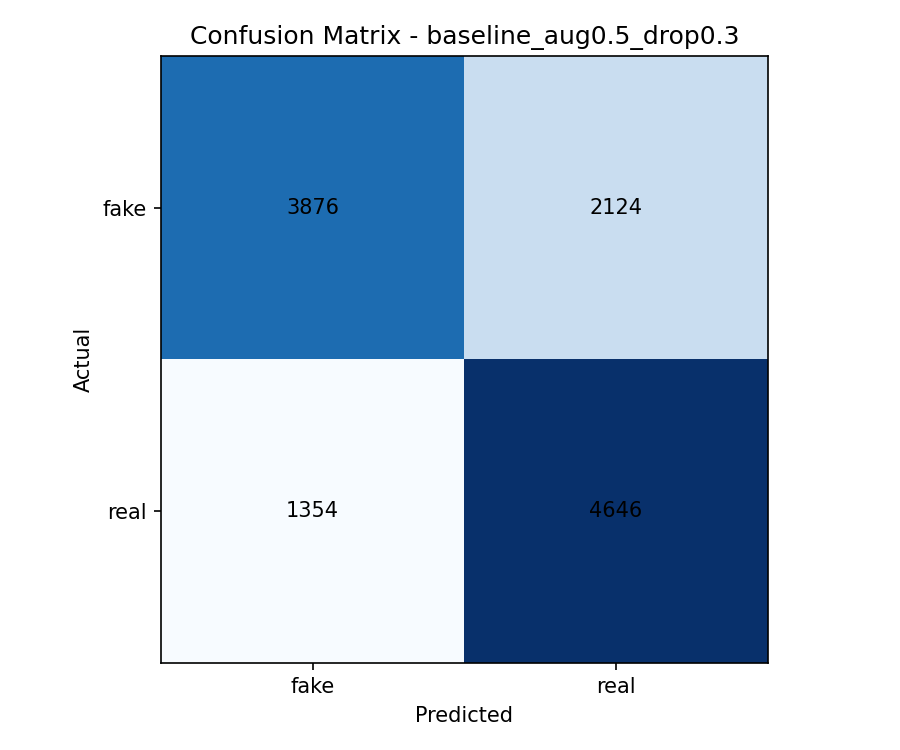

/kaggle/working/results/reports/baseline_aug0.5_drop0.3/roc_curve.png


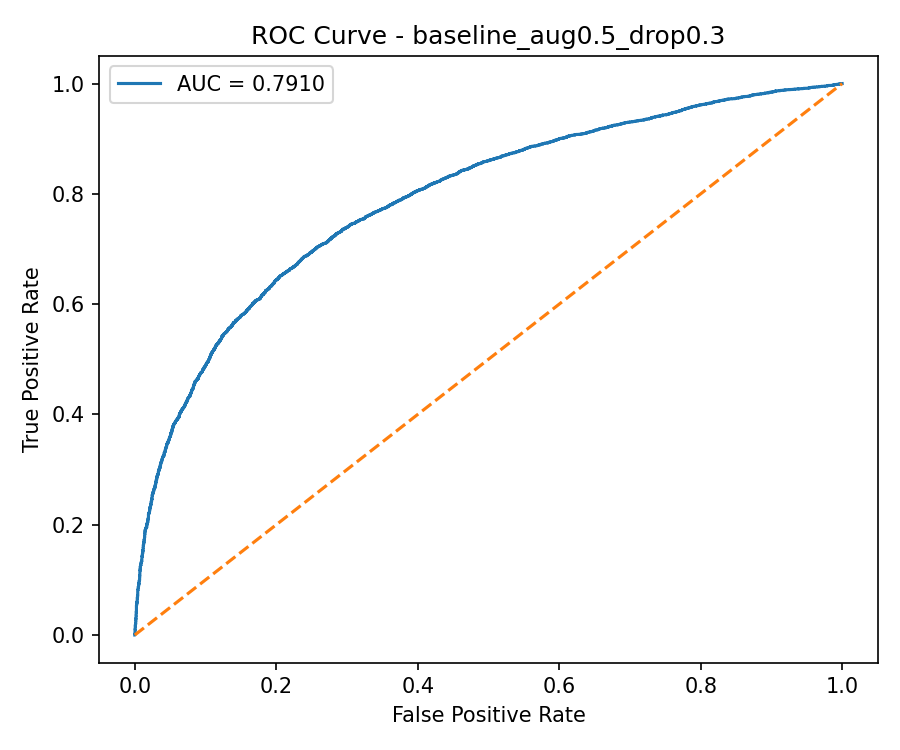

/kaggle/working/results/reports/baseline_aug1.0_drop0.3/confusion_matrix.png


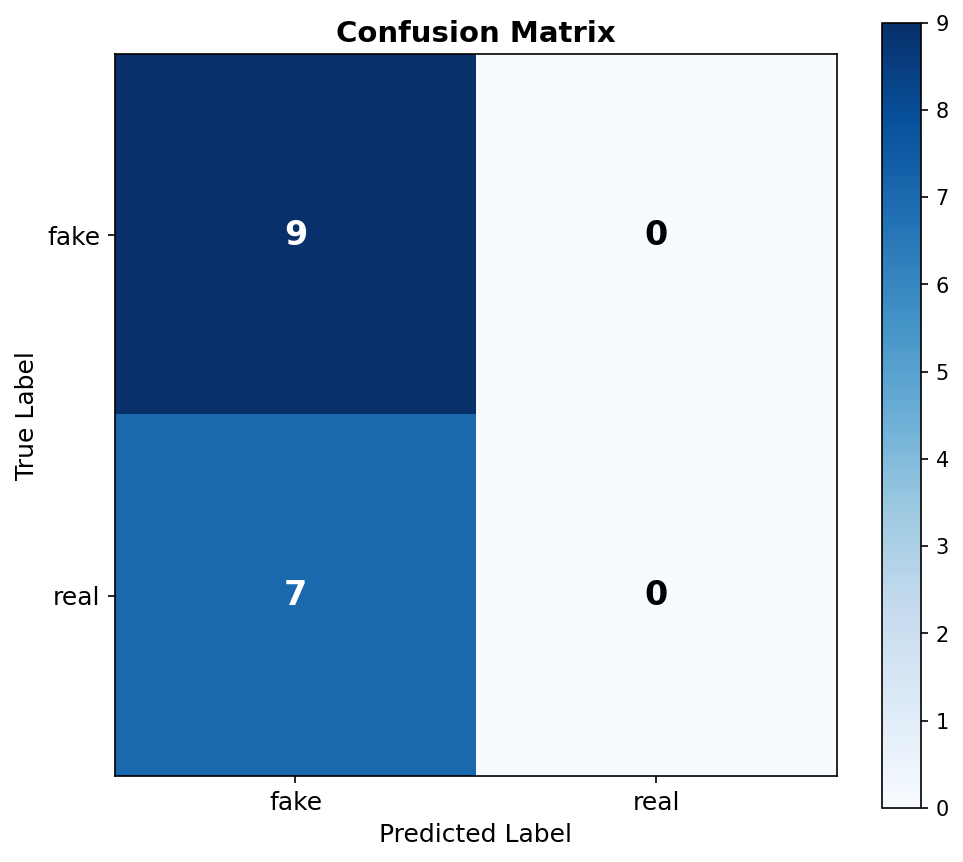

/kaggle/working/results/reports/baseline_aug1.0_drop0.3/roc_curve.png


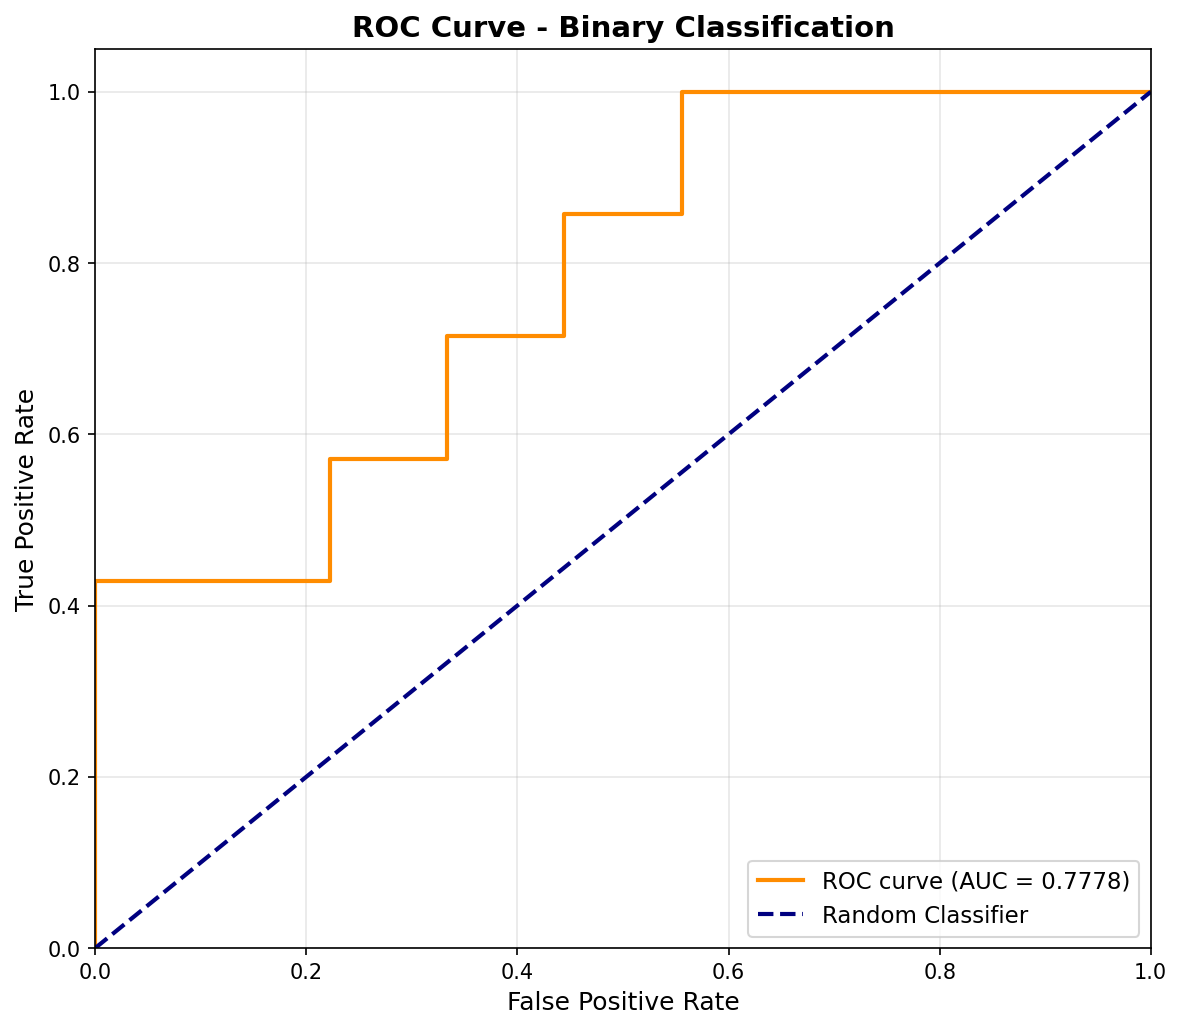

/kaggle/working/results/reports/resnet18_aug0.5_drop0.3/confusion_matrix.png


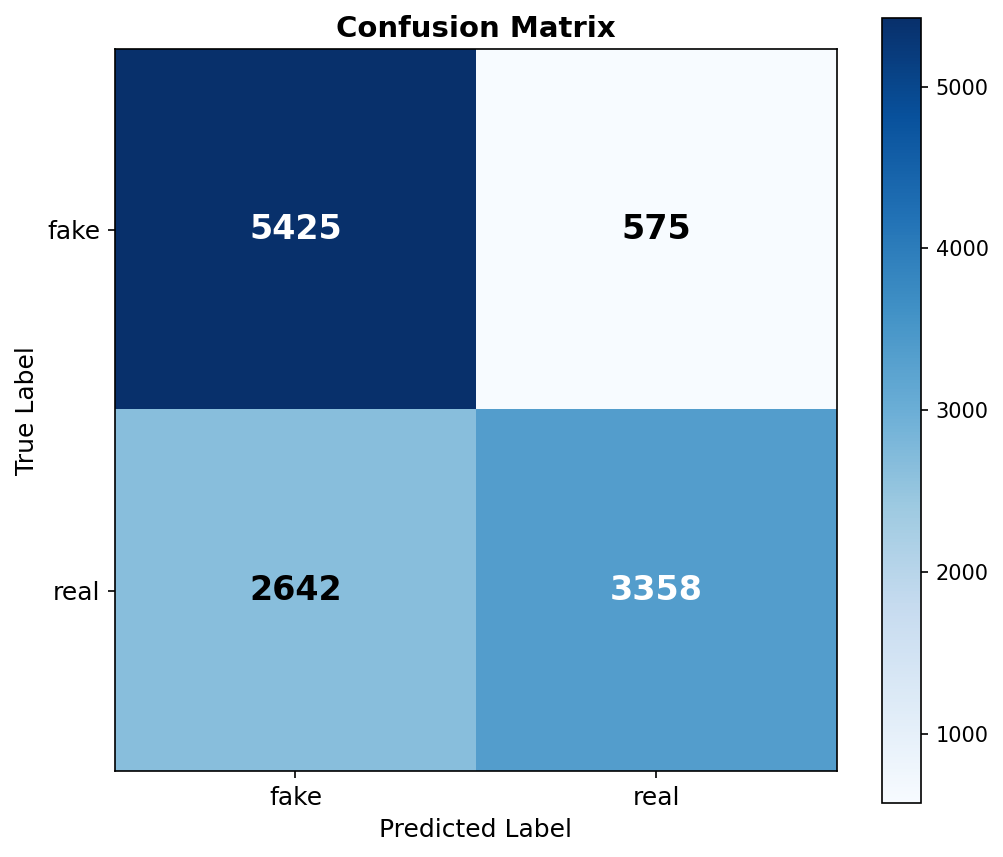

/kaggle/working/results/reports/resnet18_aug0.5_drop0.3/roc_curve.png


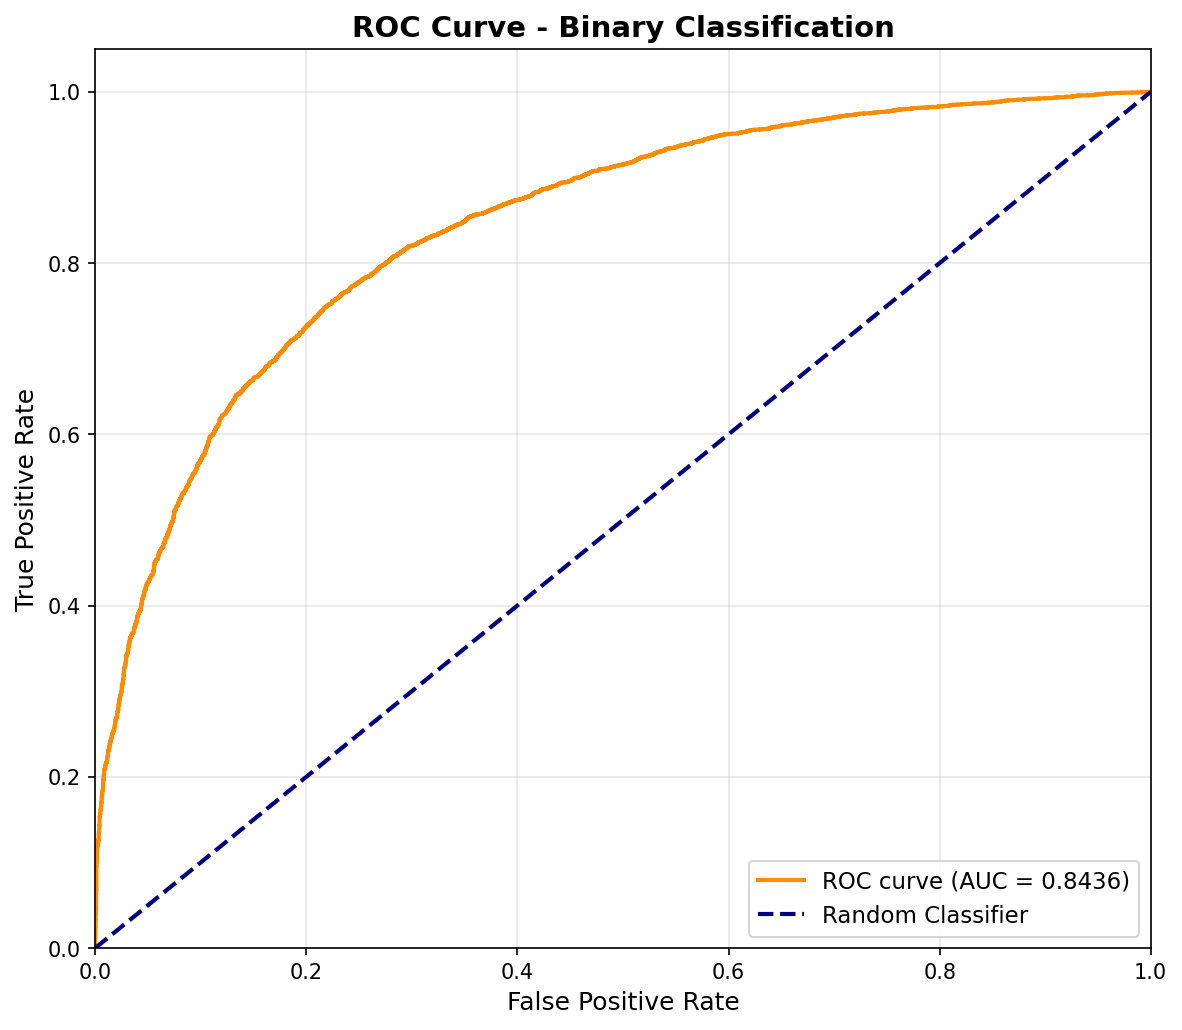

/kaggle/working/results/reports/resnet18_aug0.5_drop0.5/confusion_matrix.png


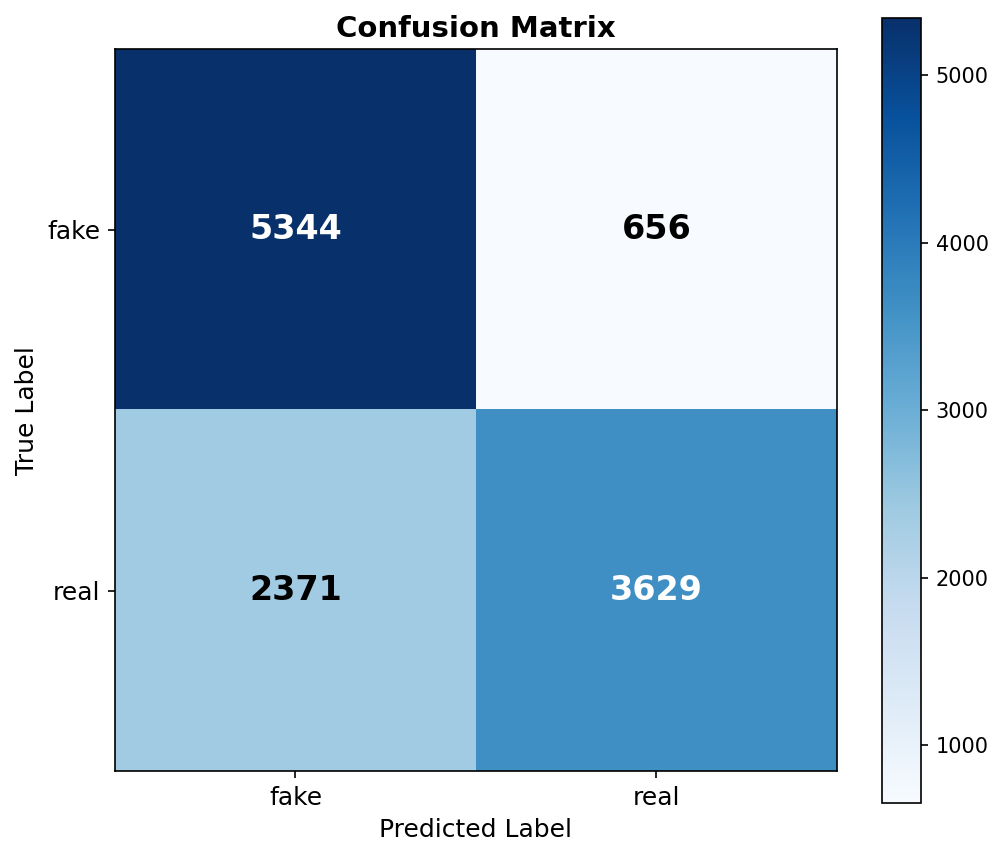

/kaggle/working/results/reports/resnet18_aug0.5_drop0.5/roc_curve.png


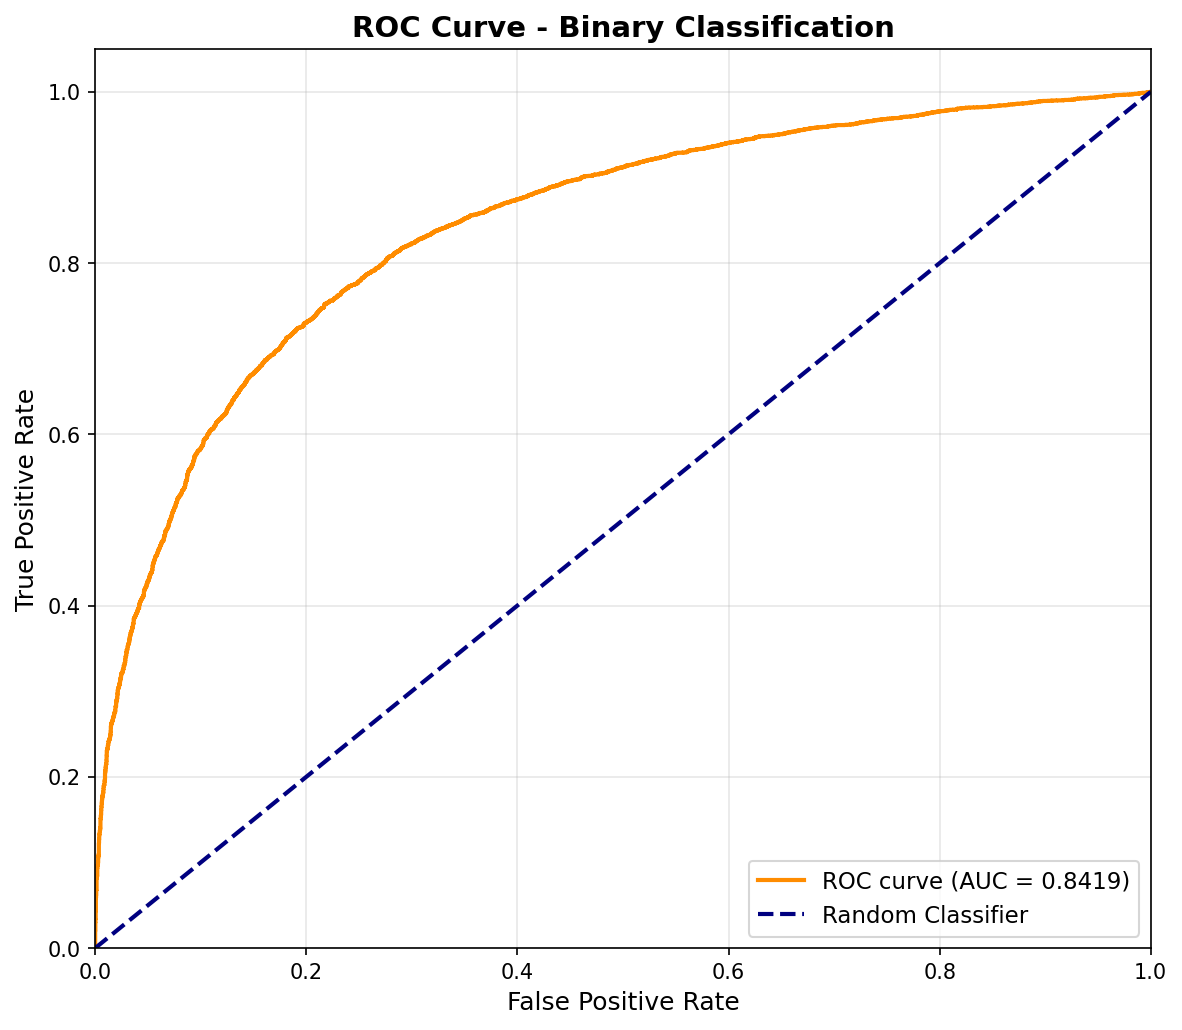

/kaggle/working/results/reports/resnet18_aug1.0_drop0.3/confusion_matrix.png


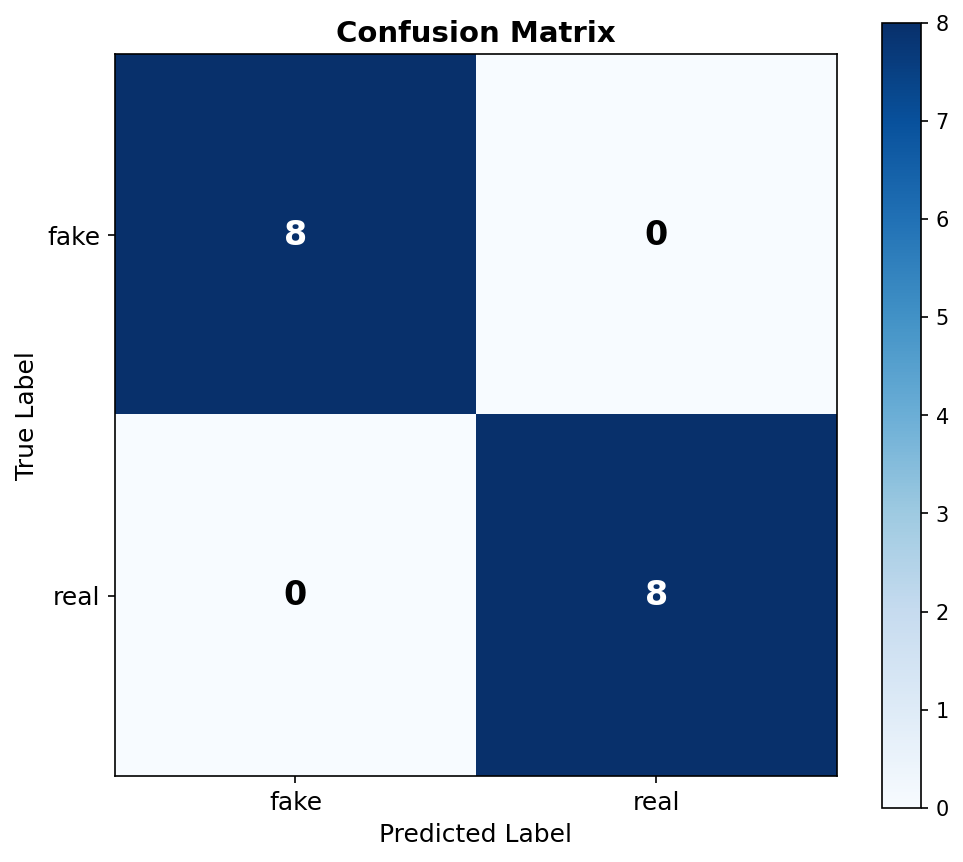

/kaggle/working/results/reports/resnet18_aug1.0_drop0.3/roc_curve.png


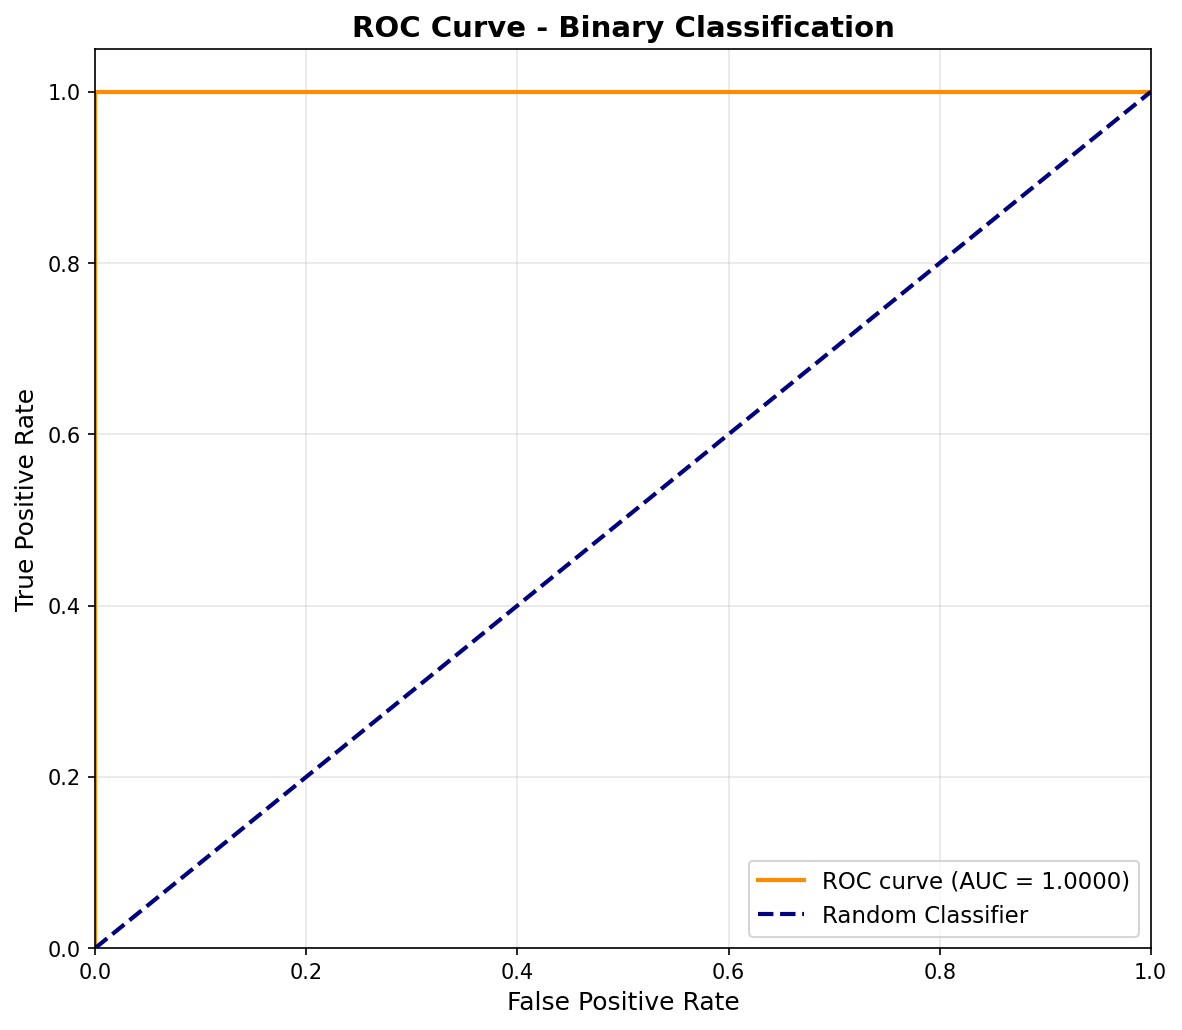

Saved:
/kaggle/working/results/final_report.md
/kaggle/working/results/final_report.html


In [37]:
import csv, json, os
from pathlib import Path
from html import escape
from IPython.display import HTML, Image, display

RESULTS_DIR = Path("/kaggle/working/results")
CSV_PATH = RESULTS_DIR / "experiments.csv"
REPORT_OUT = RESULTS_DIR / "final_report.md"
HTML_OUT = RESULTS_DIR / "final_report.html"

def to_float(x):
    try:
        return float(x)
    except Exception:
        return None

def is_real_run(row):
    t = to_float(row.get("train_time_sec", ""))
    # Dummy/smoke rows took only seconds. Real Kaggle runs took thousands of seconds.
    return t is None or t >= 600

with open(CSV_PATH, newline="") as f:
    rows = list(csv.DictReader(f))

real_rows = [r for r in rows if is_real_run(r)]
dummy_rows = [r for r in rows if not is_real_run(r)]

# Keep the latest/biggest real result for each config.
best_by_config = {}
for r in real_rows:
    key = (r["architecture"], r["augmentation_strength"], r["dropout_rate"])
    old = best_by_config.get(key)
    if old is None:
        best_by_config[key] = r
    else:
        old_t = to_float(old.get("train_time_sec", "")) or 0
        new_t = to_float(r.get("train_time_sec", "")) or 0
        if new_t >= old_t:
            best_by_config[key] = r

real_rows = list(best_by_config.values())

metric_cols = [
    "architecture", "augmentation_strength", "dropout_rate",
    "final_val_acc", "final_precision", "final_recall", "final_f1", "roc_auc",
    "train_time_sec"
]

def fmt(x):
    v = to_float(x)
    if v is None:
        return str(x)
    return f"{v:.4f}"

print("PROJECT SUMMARY")
print("=" * 70)
print("Task: binary classification of real vs AI-generated images.")
print("Dataset: Kaggle AI-Generated Images vs Real Images.")
print("Models used: baseline CNN and ResNet-18.")
print("Input size: 128x128 RGB images.")
print("Training: Adam optimizer, cross-entropy loss, early stopping on validation macro-F1.")
print("Reports saved: experiments.csv, checkpoints, confusion matrices, ROC curves.")
print()

print("IGNORED DUMMY/SMOKE ROWS:", len(dummy_rows))
print("REAL RUNS USED FOR REPORT:", len(real_rows))
print()

html = "<h2>Real Experiment Results</h2>"
html += "<table border='1' style='border-collapse:collapse'>"
html += "<tr>" + "".join(f"<th style='padding:6px'>{escape(c)}</th>" for c in metric_cols) + "</tr>"
for r in real_rows:
    html += "<tr>" + "".join(f"<td style='padding:6px'>{escape(fmt(r.get(c,'')))}</td>" for c in metric_cols) + "</tr>"
html += "</table>"
display(HTML(html))

# Pick best run by F1.
best = None
for r in real_rows:
    if best is None or (to_float(r["final_f1"]) or -1) > (to_float(best["final_f1"]) or -1):
        best = r

if best:
    print("BEST RUN BY F1")
    print("=" * 70)
    print(f"Architecture: {best['architecture']}")
    print(f"Augmentation strength: {best['augmentation_strength']}")
    print(f"Dropout: {best['dropout_rate']}")
    print(f"Accuracy: {fmt(best['final_val_acc'])}")
    print(f"F1: {fmt(best['final_f1'])}")
    print(f"ROC-AUC: {fmt(best['roc_auc'])}")
    print()

print("FIGURES")
print("=" * 70)
for img in sorted((RESULTS_DIR / "reports").glob("*/*.png")):
    print(img)
    display(Image(filename=str(img)))

md = []
md.append("# CNN AI Image Detection Report\n")
md.append("## Method\n")
md.append("- Binary classification: real vs AI-generated images.")
md.append("- Dataset: Kaggle AI-Generated Images vs Real Images.")
md.append("- Models: baseline CNN and ResNet-18.")
md.append("- Preprocessing: resize to 128x128, ImageNet normalization.")
md.append("- Training: Adam optimizer, cross-entropy loss, early stopping using validation macro-F1.")
md.append("- Evaluation: accuracy, precision, recall, macro-F1, ROC-AUC, confusion matrix, ROC curve.\n")

md.append("## Real Runs Used\n")
for r in real_rows:
    md.append(
        f"- {r['architecture']} | aug={r['augmentation_strength']} | dropout={r['dropout_rate']} | "
        f"acc={fmt(r['final_val_acc'])} | f1={fmt(r['final_f1'])} | auc={fmt(r['roc_auc'])}"
    )

if best:
    md.append("\n## Main Finding\n")
    md.append(
        f"The best observed configuration was **{best['architecture']}** with "
        f"augmentation strength **{best['augmentation_strength']}** and dropout **{best['dropout_rate']}**, "
        f"achieving accuracy **{fmt(best['final_val_acc'])}**, macro-F1 **{fmt(best['final_f1'])}**, "
        f"and ROC-AUC **{fmt(best['roc_auc'])}**."
    )

md.append("\n## Notes\n")
md.append("- Very short runs in `experiments.csv` were smoke/dummy tests and were excluded from this report.")
md.append("- These results use the available train/test split, not a full leave-one-generator-out split.")

REPORT_OUT.write_text("\n".join(md), encoding="utf-8")

html_report = "<html><body style='font-family:Arial'>"
html_report += "<h1>CNN AI Image Detection Report</h1>"
html_report += html
html_report += "<h2>Figures</h2>"
for img in sorted((RESULTS_DIR / "reports").glob("*/*.png")):
    rel = img.relative_to(RESULTS_DIR)
    html_report += f"<h3>{escape(str(rel))}</h3><img src='{escape(str(rel))}' style='max-width:700px'>"
html_report += "</body></html>"
HTML_OUT.write_text(html_report, encoding="utf-8")

print("Saved:")
print(REPORT_OUT)
print(HTML_OUT)


In [38]:
!zip -r /kaggle/working/results.zip /kaggle/working/results


  adding: kaggle/working/results/ (stored 0%)
  adding: kaggle/working/results/resnet18_aug0.5_drop0.3/ (stored 0%)
  adding: kaggle/working/results/resnet18_aug0.5_drop0.3/history.json (deflated 38%)
  adding: kaggle/working/results/resnet18_aug0.5_drop0.3/best.pth (deflated 9%)
  adding: kaggle/working/results/final_report.md (deflated 45%)
  adding: kaggle/working/results/baseline_aug0.5_drop0.3/ (stored 0%)
  adding: kaggle/working/results/baseline_aug0.5_drop0.3/history.json (deflated 39%)
  adding: kaggle/working/results/baseline_aug0.5_drop0.3/best.pth (deflated 9%)
  adding: kaggle/working/results/experiments.csv (deflated 78%)
  adding: kaggle/working/results/resnet18_aug0.5_drop0.5/ (stored 0%)
  adding: kaggle/working/results/resnet18_aug0.5_drop0.5/history.json (deflated 43%)
  adding: kaggle/working/results/resnet18_aug0.5_drop0.5/best.pth (deflated 8%)
  adding: kaggle/working/results/reports/ (stored 0%)
  adding: kaggle/working/results/reports/resnet18_aug0.5_drop0.3/ (